# Braintracer Cell Analysis
Braintracer extends the functionality of cellfinder and brainreg. It takes the downsampled data, registered atlas, and positive cell coordinates, scales them down to downsampled space and assigns them to corresponding atlas brain areas, cleanly displaying the results from multiple datasets.

### Setup

In [1]:
from braintracer.braintracer import analysis as bt
from braintracer.braintracer import file_management as btf
from braintracer.braintracer import plotting as btp
from braintracer.braintracer import area_lists as bta
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from tqdm import tqdm
import scipy.stats as stats
import brainglobe_heatmap as bgh
from scipy.optimize import minimize

In [2]:
## DEFINE YOUR EXPERIMENT
def retro_expts():
    bt.postsyn_region = 'IO' # You must set a starter region to use some features
    # For quantifications comparing pre and postsynaptic cell populations, you must set the following:
    bt.postsyn_ch = 'r' # The channel(s) containing starter cells (postsynaptics)
    bt.presyn_ch = 'r' # The channel(s) containing input cells (presynaptics)
    bt.presyn_regions_exclude = ['CBX'] # Presynaptic cells are the total cells in presyn_ch - (postsyn_region + presyn_regions_exclude)

    bt.channel_colours = ['r','g','b'] # ordered list of colours channels will take ['r','g','b'] by default
    bt.resolution_total = 20
    bt.network_name = 'bt14' # default is Unet
    bt.grouped = True # True by default, set to False if you only have one group
    bt.debug = False # False by default
    #bt.spatial_segregation_calculation_threshold = 0.01
    
def antero_expts_override():
    bt.postsyn_region = 'CBX'
    bt.presyn_regions_exclude = ['CBN', 'P', 'IO', 'icp']
    
retro_expts()
antero_expts_override()

# normalisation:
# * None - use cell count
# * 'presynaptics' - normalise to the presynaptic cell count
# * 'postsynaptics' - normalise to the postsynaptic cell count
# * 'total' - normalise to the total cell count in the first channel name in Dataset instantiation parameter
# orientation: 'frontal', 'sagittal', 'horizontal' or a tuple (x,y,z)
# poster plotting: plt.style.use('seaborn-poster')

In [3]:
cb = [58920000000, 19150000000, 24760000000, 36480000000, 53200000000, 40880000000, 26600000000, 21890000000]
# make sure to normalise dividing factors around 1
def norm(values, idx):
    divisor = (sum(values) / len(values)) / values[idx]  # relative to 1 (mean)
    return 1 / divisor # inverse because dividing by norm value

In [4]:
# provide the name, group, cell channels, background channel
# LOW CELL COUNTS TO BE EXCLUDED FOR PROBABILITY MAPS: FR195, FR197, FR198, FR209, FR210, SC017, SC028, SC034
## EXCLUDED
bt.network_name = 'Unet'
#bt.Dataset('FR195', 'LS', ['r','g']);
#bt.Dataset('FR211', 'LS', ['r','g']); # CANNOT RUN; has zero cells
#bt.Dataset('SC002', 'LS', ['r','g'], atlas_25=True);
#bt.Dataset('SC004', 'LS', ['r','g']); # CANNOT RUN; never ran cellfinder
bt.network_name = 'bt14' # default is Unet
#bt.Dataset('SC017', 'LS', ['r','g']);
#bt.Dataset('FR198', 'LS', ['r','g'], starters=15);
#bt.Dataset('FR209', 'LS', ['r','g'], starters=59);
#bt.Dataset('FR210', 'LV', ['r','g'], starters=291);
#bt.Dataset('SC028', 'LS', ['r']);
#bt.Dataset('SC029', 'LS', ['r']);
#bt.Dataset('SC034', 'LS', ['r']);
## INCLUDED
bt.network_name = 'Unet' # datasets which haven't been analysed yet with bt14
#bt.Dataset('FR208', 'LV', ['r', 'g']);
#bt.Dataset('SC005', 'LS', ['r', 'g']);
bt.network_name = 'bt14' # default is Unet
## Lobule Simplex
bt.Dataset('SC003', 'LS', ['r'], true_postsynaptics=229, atlas_25=True);
bt.Dataset('SC009', 'LS', ['r']);
bt.Dataset('FR200', 'LS', ['r'], true_postsynaptics=1102); # these starters values override the cellfinder count in the starter region for normalisation purposes
bt.Dataset('SC007', 'LS', ['r']);
bt.Dataset('SC008', 'LS', ['r']);
bt.Dataset('SC010', 'LS', ['r']); # CHANGED from human-defined LV
bt.Dataset('SC011', 'LS', ['r'], true_postsynaptics=202);
bt.Dataset('SC030', 'LS', ['r']);

## Lobule V
bt.Dataset('FR197', 'LV', ['r']);
bt.Dataset('FR199', 'LV', ['r'], true_postsynaptics=477);
bt.Dataset('SC001', 'LV', ['r'], true_postsynaptics=336, atlas_25=True);
bt.Dataset('SC006', 'LV', ['r'], true_postsynaptics=242);
bt.Dataset('SC012', 'LV', ['r']);
bt.Dataset('SC016', 'LV', ['r']);
bt.Dataset('SC018', 'LV', ['r'], true_postsynaptics=278);
bt.Dataset('SC027', 'LV', ['r']);
bt.Dataset('SC031', 'LV', ['r']);

bt.Dataset('SC013', 'LS', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,0));
bt.Dataset('SC014', 'LV', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,1));
bt.Dataset('SC015', 'LS', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,2));
bt.Dataset('SC020', 'LS', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,3));
bt.Dataset('SC022', 'LS', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,4));
bt.Dataset('SC023', 'LV', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,5));
bt.Dataset('SC048', 'LV', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,6));
bt.Dataset('SC049', 'LV', ['r'], fluorescence=True, skimmed=True, true_postsynaptics=norm(cb,7));
title = '_'.join([i.name for i in bt.datasets])

### Region setup funcs

In [5]:
# only used for post-processing just before being plotted, so ensure that changes you make here are only used on sets of areas with non-overlapping information
areas_to_combine_that_fix_atlas_issues = {'Pontine reticular nucleus': [146, 1093],
                                          'Spinal nucleus of the trigeminal': [429, 437, 445]}
areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default = {'Pontine reticular nucleus': [146, 1093],
                                                                       'Spinal nucleus of the trigeminal': [429, 437, 445],
                                                                       'Mesodiencephalic junction': [67, 587, 549009211, 6020]}
areas_to_combine_that_arent_present_by_default = {'Mesodiencephalic junction': [67, 587, 549009211, 6020]}

In [6]:
all_incf_title = 'Retro disynaptic CF input map'
all_inmf_title = 'Antero monosynaptic MF input map'
all_otmo_title = 'Antero monosynaptic output map'
all_otdi_title = 'Antero disynaptic output map'

In [7]:
def try_append(start_list, item):
    if item not in start_list:
        start_list.append(item)

In [8]:
def add_PRN_areas(to_list):
    # ensure PRNr and PRNc are present for combining (because one of them usually shows up)
    try_append(to_list, 146)
    try_append(to_list, 1093)

In [9]:
def add_SPnT_areas(to_list):
    # ensure SPVO, SPVI and SPVC are present for combining (because one of them usually shows up)
    try_append(to_list, 445)
    try_append(to_list, 437)
    try_append(to_list, 429)

In [10]:
def add_MDJ_areas(to_list):
    # ensure IC, ND and MA3 are present for combining (because one of them usually shows up) (even though IC and ND overlap with Allen definition of PAG)
    try_append(to_list, 67) # Interstitial nucleus of Cajal
    try_append(to_list, 587) # Nucleus of Darkschewitsch
    try_append(to_list, 549009211) # Medial accessory oculomotor nucleus
    try_append(to_list, 6020) # custom MDJ region

In [11]:
def replace_all_children_with_parent_if_a_child_is_present(parent, in_list):
    children = bt.children_from(parent, depth=0)[1]
    any_children_present = any(item in in_list for item in children)
    if any_children_present:
        in_list = [item for item in in_list if item not in children] # filter out m1 children
        try_append(in_list, parent)
    return in_list

In [12]:
def get_di_input_areas():
    rg_di_areas, rg_di_title = bta.di_inputs_retro(0.5, 'total', False)
    rg_di_areas = replace_all_children_with_parent_if_a_child_is_present(985, rg_di_areas) # M1 sublayers
    rg_di_areas = replace_all_children_with_parent_if_a_child_is_present(993, rg_di_areas) # M2 sublayers
    rg_di_areas = replace_all_children_with_parent_if_a_child_is_present(294, rg_di_areas) # SCm sublayers
    add_PRN_areas(to_list=rg_di_areas)
    add_SPnT_areas(to_list=rg_di_areas)
    add_MDJ_areas(to_list=rg_di_areas)
    return rg_di_areas, rg_di_title

## Region setup

In [13]:
rg_di_areas, rg_di_title = get_di_input_areas()
rg_mi_areas, rg_mi_title = bta.inputs_antero_CF()
io_title = 'CF inputs (TRIO retrograde)'

In [14]:
ag_mi_areas, ag_mi_title = bta.inputs_antero_MF_roi_crop()
add_PRN_areas(to_list=ag_mi_areas)
add_SPnT_areas(to_list=ag_mi_areas)

In [15]:
ag_cb_areas, ag_cb_title = bta.cerebellar_cortex_antero_custom()

In [16]:
ag_mo_areas, ag_mo_title = bta.mono_outputs_antero()

In [17]:
ag_do_areas, ag_do_title = bta.di_outputs_antero_roi(0.0001, None, True)
try_append(ag_do_areas, 718) # VPL
add_MDJ_areas(to_list=ag_do_areas)

In [18]:
title_m = ag_mo_title + ' + ' + ag_mi_title
title_d = rg_di_title + ' + ' + ag_do_title
title_ii = ag_mi_title + ' + ' + rg_di_title

In [19]:
m_areas = list(set(ag_mi_areas + ag_mo_areas))
d_areas = list(set(rg_di_areas + ag_do_areas))
ii_areas = list(set(ag_mi_areas + rg_di_areas))

In [20]:
all_areas = list(set(rg_di_areas + ag_mi_areas + ag_mo_areas + ag_do_areas))
all_areas_func = bta.custom_rois(all_areas)

In [21]:
## Figure 2 data
fig2_areas = [528, 519, 83, 771, 795, 701, 235, 372, 574] # ['CBX', 'CBN', 'IO', 'P', 'PAG', 'VNC', 'LRN', 'ICB', 'TRN']
fig2_dmap_subregions = [[1007,928], [846,989,91,589508455], None, [931, 574], None, None, None, None, None]
fig2_scat_ulim = [100, 50, 10, 10, 10, 10, 10, 10, 10]
fig2_dmap_axes = [1, 2, 2, 2, 2, 2, 2, 2, 2]
fig2_dmap_sat = [3, 3, 3, 3, 3, 3, 3, 3, 3]

In [24]:
## Figure 5 data
fig5_areas = [83, 997, [6020, 67, 587, 549009211], 500, 549, 771, 519, 294] # ['IO', 'Brain', 'MDJ', 'MO', 'TH', 'P', 'CBN', 'SCm'] # Cerebellum is done in 'bt_retroBlue.ipynb'
fig5_dmap_subregions = [ None, [528, 83, 795, 294, 500, 549, 771, 519], None, None, [406, 1029, 685], [146, 1093], None, None]
fig5_scat_ulim = [10, 20, 10, 5, 10, 10, 10, 10]
fig5_dmap_axes = [2, 0, 2, 2, 2, 2, 2, 2]
fig5_dmap_sat = [3, 30, 3, 3, 3, 3, 3, 3]
fig5_dmap_subregions_to_mask = [[],[528],[],[],[],[],[],[]]

In [23]:
## Figure 7 data
fig7_areas = [629, 214, 907] # ['VAL', 'PCN', 'RN']
fig7_dmap_subregions = [None, None, None]
fig7_dmap_axes = [2, 2, 2]
fig7_dmap_sat = [3, 3, 3]

### Begin plotting

Watch out! Remove padding for areas that touch the edge of the atlas.
Watch out! Remove padding for areas that touch the edge of the atlas.
Upper limit: 0.0006328184511129175
Upper limit: 0.006519605740076765
Upper limit: 0.021636962096314622
Upper limit: 0.0053895594525465015
Upper limit: 0.00896079783626801
Upper limit: 0.010615862653362082
Upper limit: 0.006931802231452518
Upper limit: 0.03613196306756129
Upper limit: 0.009536268670395476


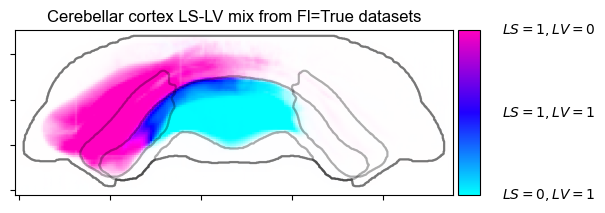

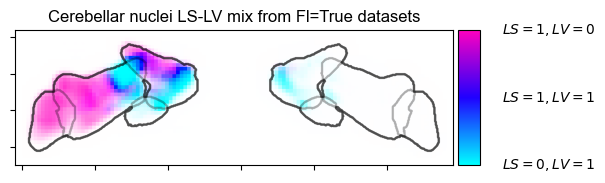

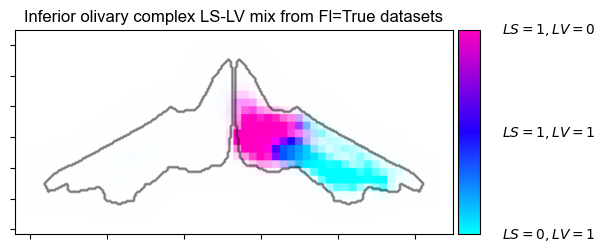

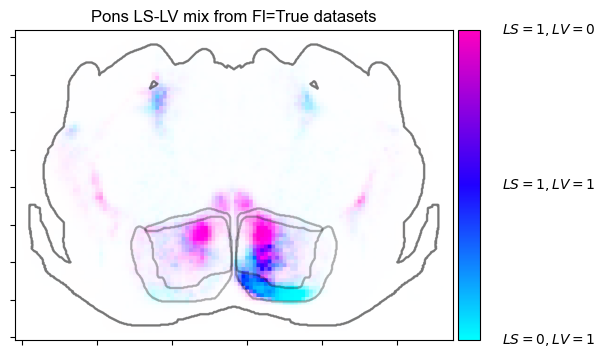

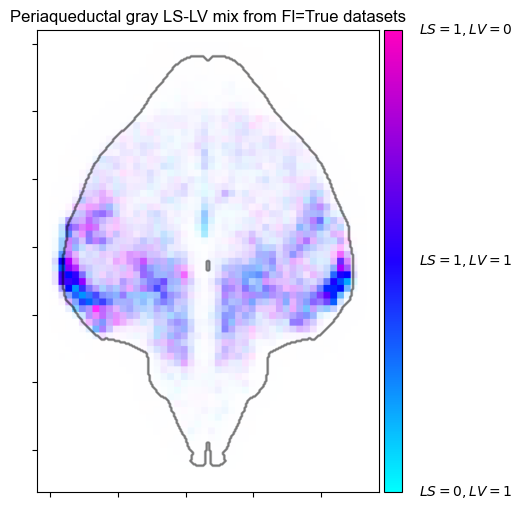

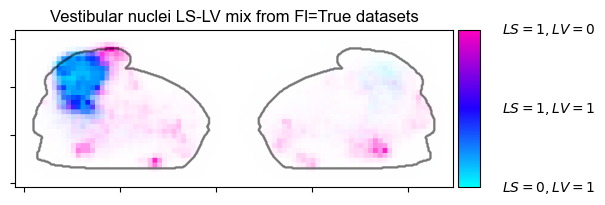

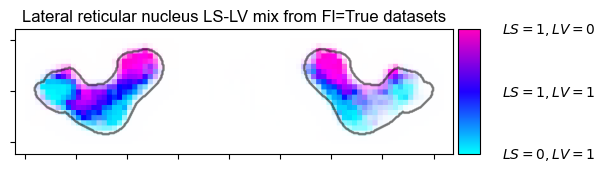

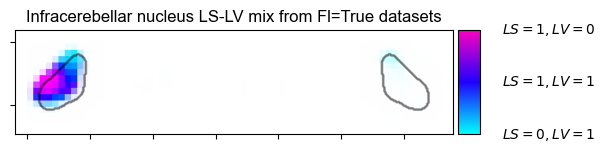

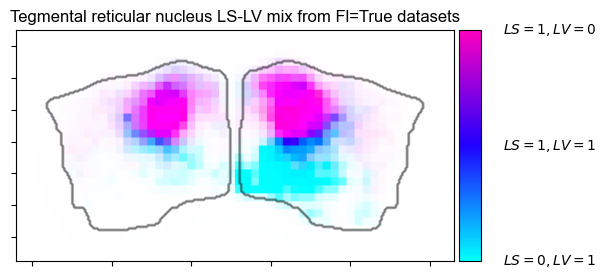

In [24]:
for area, subregions, axis, sat in zip(fig2_areas, fig2_dmap_subregions, fig2_dmap_axes, fig2_dmap_sat):
        btp.probability_map_overlap('r', True, area_num=area, subregions=subregions, binsize=50, axis=axis, sigma=0.5, projcol='k', padding=10, saturation_multiplier=sat)

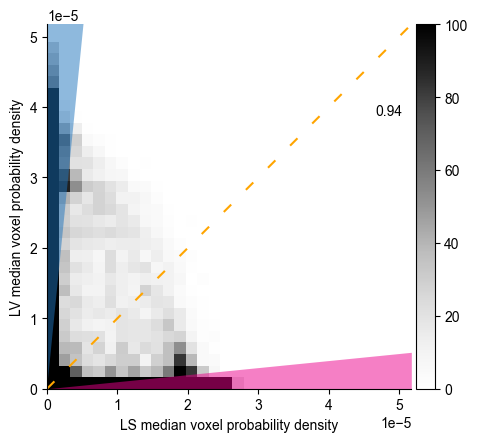

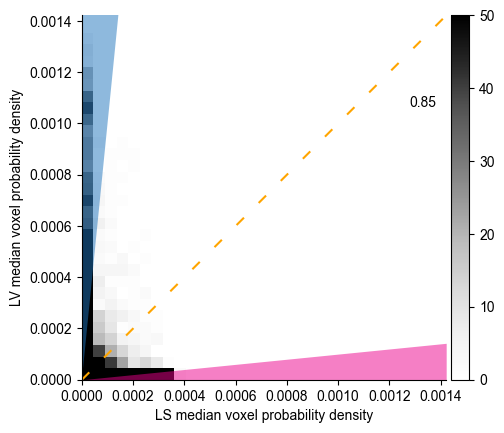

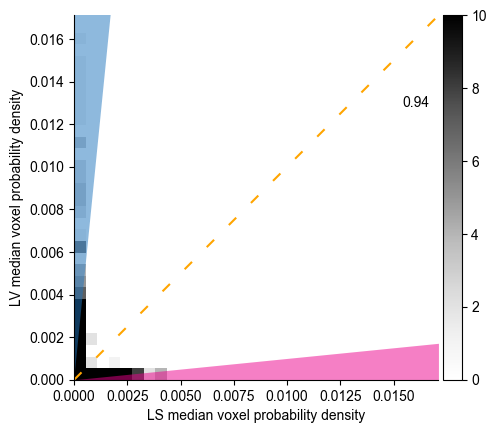

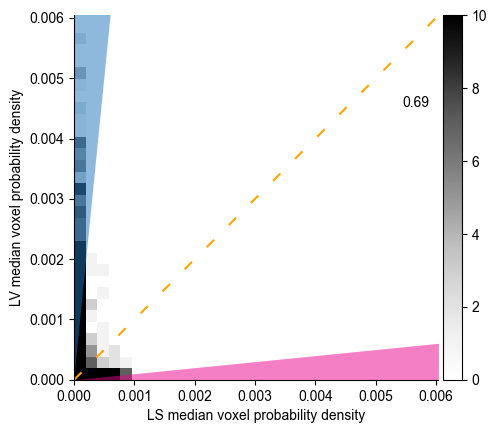

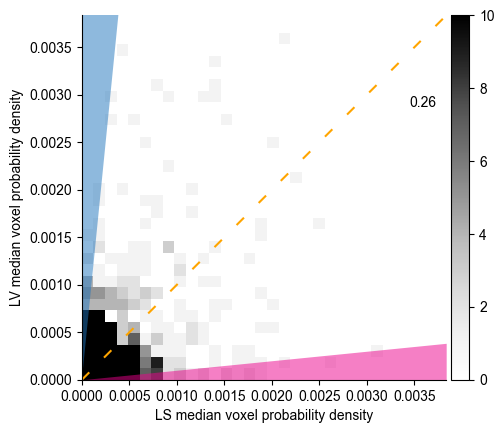

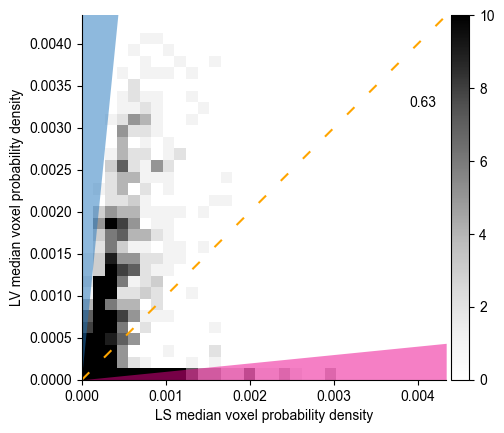

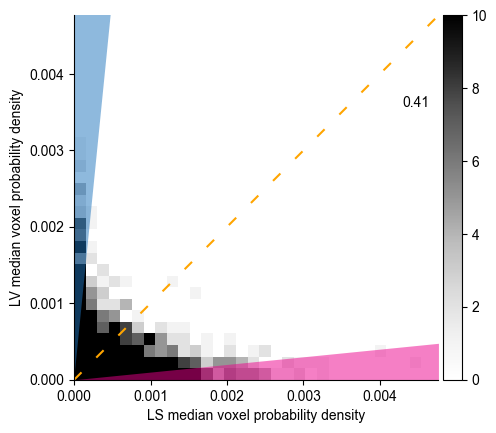

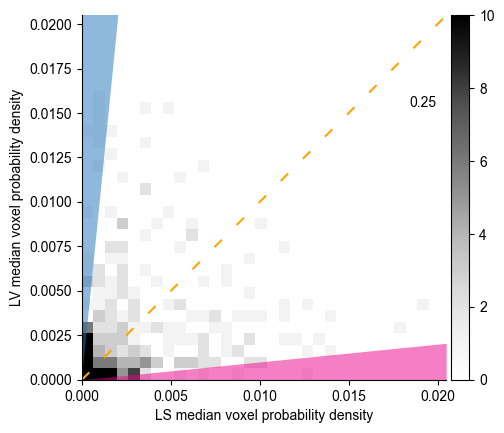

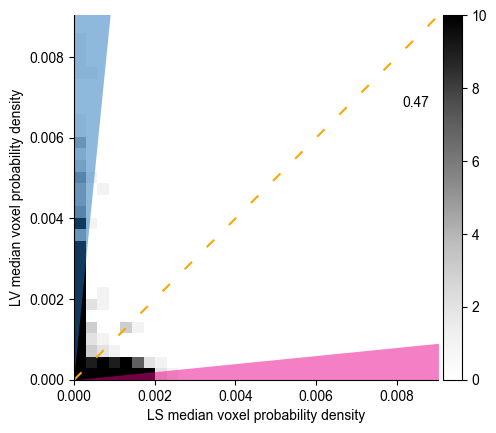

In [25]:
for area, ulim in zip(fig2_areas, fig2_scat_ulim):
        btp.pmap_corr_scatter_binned(('r', True, area, 50, 0.5), gradient=0.1, vbounds=(0, ulim))

Upper limit: 0.0032822047839810376


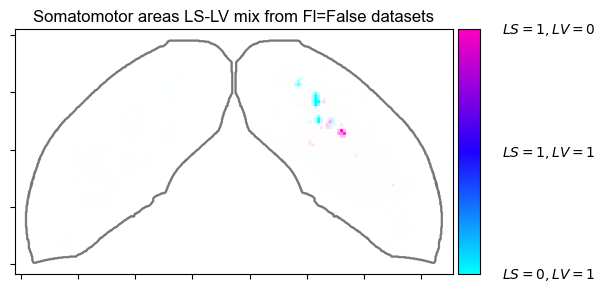

In [26]:
for area, subregions, axis, sat, mask_out in zip(fig5_areas, fig5_dmap_subregions, fig5_dmap_axes, fig5_dmap_sat, fig5_dmap_subregions_to_mask):
    if area == 500:
        padding = 10 if area != 997 else 0
        btp.probability_map_overlap('r', False, area_num=area, subregions=subregions, binsize=50, axis=axis, sigma=0.5, projcol='k', padding=padding, saturation_multiplier=sat, areas_mask_out=mask_out)

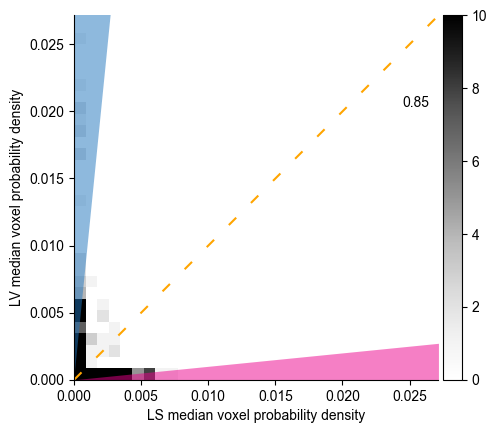

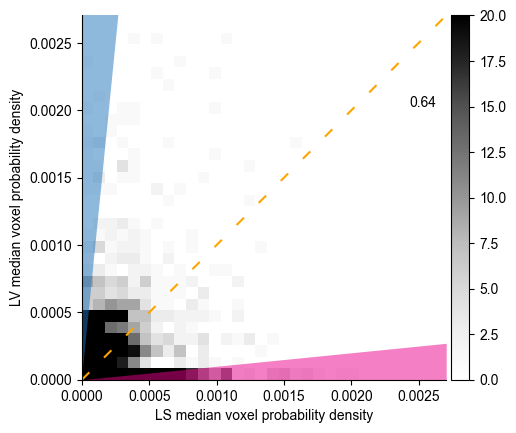

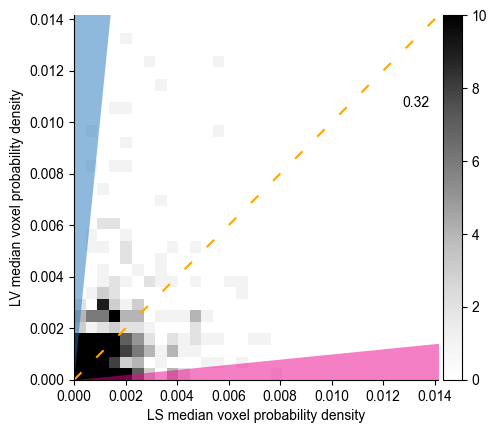

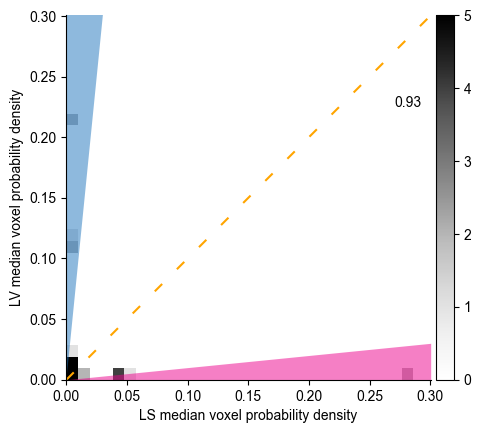

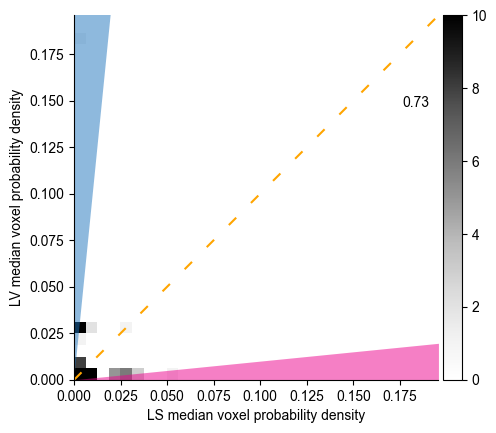

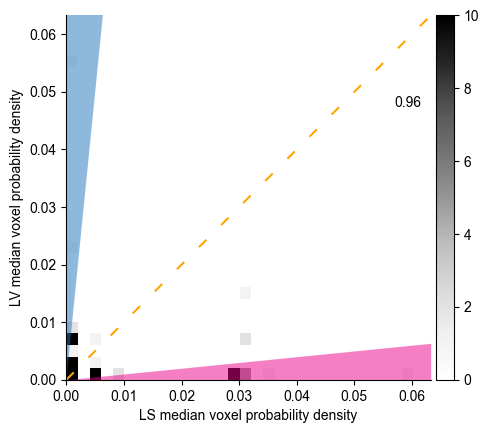

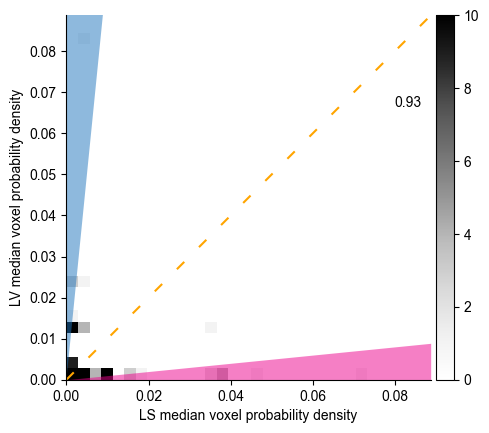

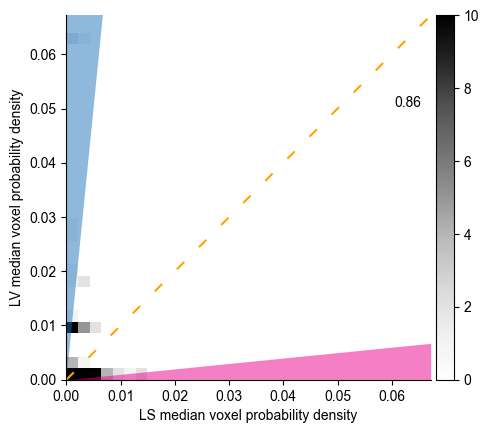

In [27]:
for area, ulim in zip(fig5_areas, fig5_scat_ulim):
        btp.pmap_corr_scatter_binned(('r', False, area, 50, 0.5), gradient=0.1, vbounds=(0, ulim))

Upper limit: 0.00877177347325548
Upper limit: 0.020100998216917864
Upper limit: 0.020342296079389893


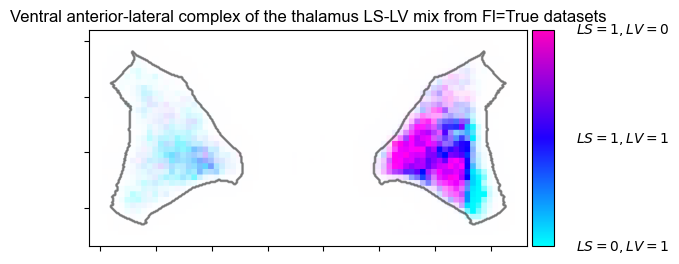

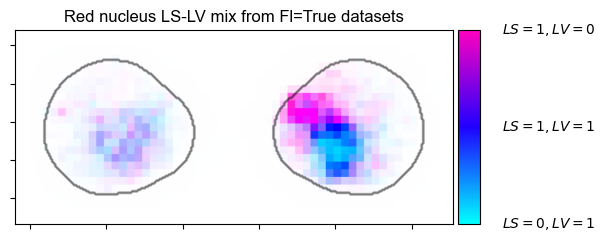

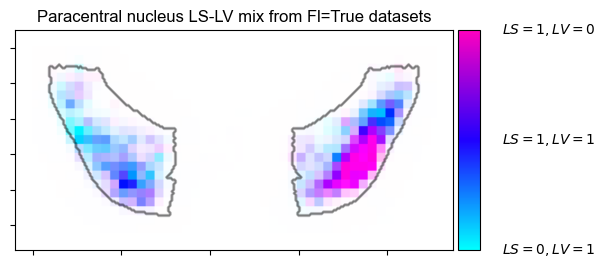

In [28]:
for area, subregions, axis, sat in zip(fig7_areas, fig7_dmap_subregions, fig7_dmap_axes, fig7_dmap_sat):
        btp.probability_map_overlap('r', True, area_num=area, subregions=subregions, binsize=50, axis=axis, sigma=0.5, projcol='k', padding=10, saturation_multiplier=sat)

# Matrices

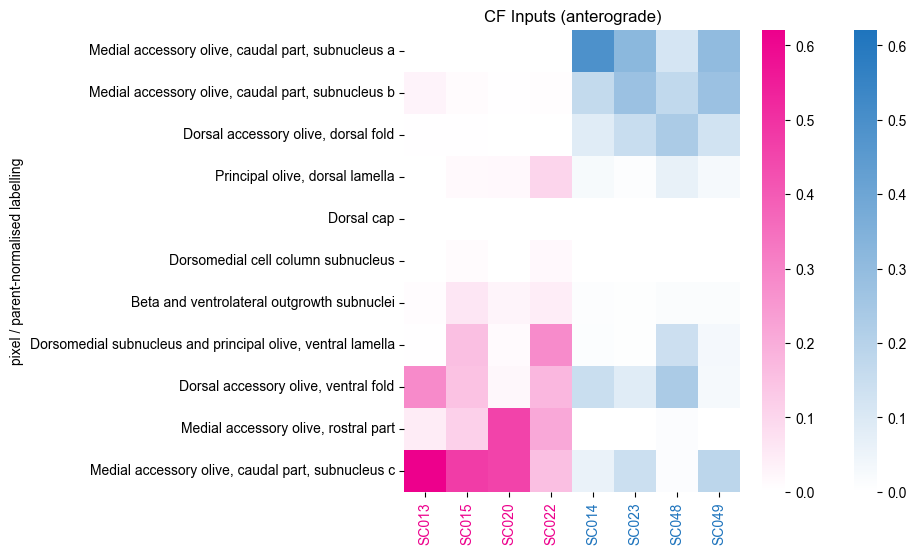

In [32]:
btp.region_signal_matrix('r', (rg_di_areas, rg_di_title), value_norm='presynaptics', figsize=(7,6), vmax=10, fluorescence=False, log_plot=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default);
btp.region_signal_matrix('r', (rg_mi_areas, io_title), value_norm='within_region', figsize=(7,6), vmax=None, fluorescence=False, log_plot=False);
btp.region_signal_matrix('r', (rg_mi_areas, rg_mi_title), value_norm='within_region', figsize=(7,6), vmax=None, fluorescence=True, log_plot=False);
btp.region_signal_matrix('r', (ag_mi_areas, ag_mi_title), value_norm=None, figsize=(7,6), vmax=0.01, fluorescence=True, log_plot=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues);
btp.region_signal_matrix('r', (ag_mo_areas, ag_mo_title), value_norm=None, figsize=(7,6), vmax=None, fluorescence=True, log_plot=False);
btp.region_signal_matrix('r', (ag_do_areas, ag_do_title), value_norm=None, figsize=(7,6), vmax=0.0014, fluorescence=True, log_plot=False, areas_to_combine=areas_to_combine_that_arent_present_by_default);

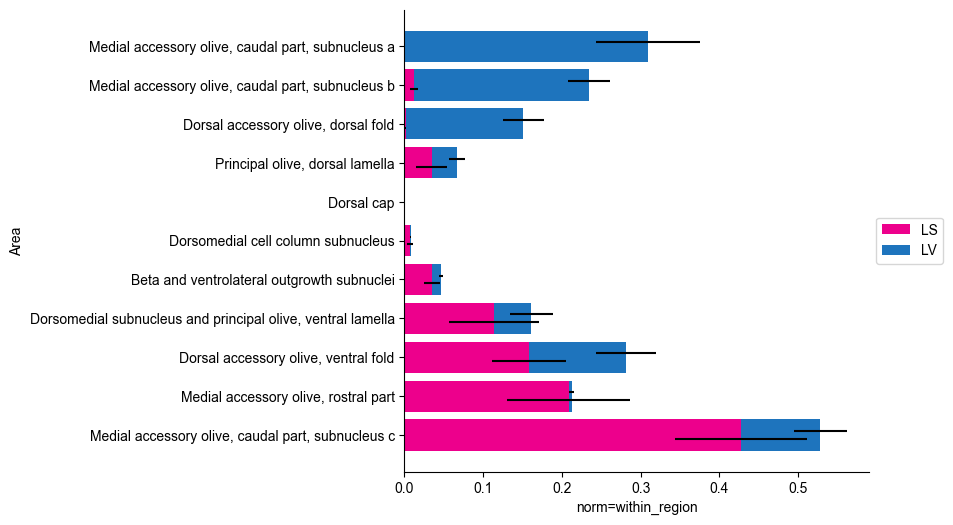

In [33]:
btp.area_total_signal_bar('r', (rg_di_areas, rg_di_title), value_norm='presynaptics', fluorescence=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.area_total_signal_bar('r', (rg_mi_areas, io_title), value_norm='within_region', fluorescence=False)
btp.area_total_signal_bar('r', (rg_mi_areas, rg_mi_title), value_norm='within_region', fluorescence=True)
btp.area_total_signal_bar('r', (ag_mi_areas, ag_mi_title), value_norm=None, fluorescence=True, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
btp.area_total_signal_bar('r', (ag_mo_areas, ag_mo_title), value_norm=None, fluorescence=True)
btp.area_total_signal_bar('r', (ag_do_areas, ag_do_title), value_norm=None, fluorescence=True, areas_to_combine=areas_to_combine_that_arent_present_by_default)

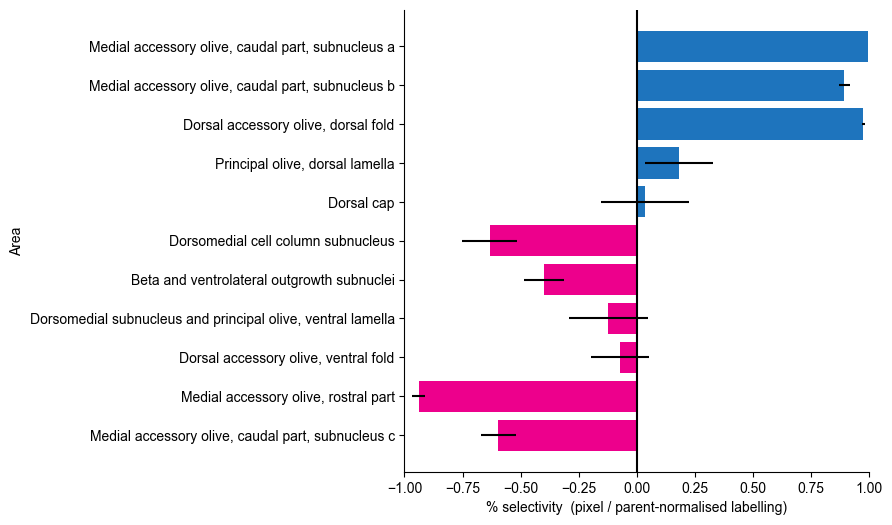

In [29]:
btp.area_selectivity_with_errors('r', (rg_di_areas, rg_di_title), value_norm='presynaptics', fluorescence=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.area_selectivity_with_errors('r', (rg_mi_areas, io_title), value_norm='within_region', fluorescence=False)
btp.area_selectivity_with_errors('r', (rg_mi_areas, rg_mi_title), value_norm='within_region', fluorescence=True)
btp.area_selectivity_with_errors('r', (ag_mi_areas, ag_mi_title), value_norm=None, fluorescence=True, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
btp.area_selectivity_with_errors('r', (ag_mo_areas, ag_mo_title), value_norm=None, fluorescence=True)#btp.area_selectivity_with_errors('r', (ag_do_areas, ag_do_title), value_norm=None, fluorescence=True, areas_to_combine=areas_to_combine_that_arent_present_by_default)

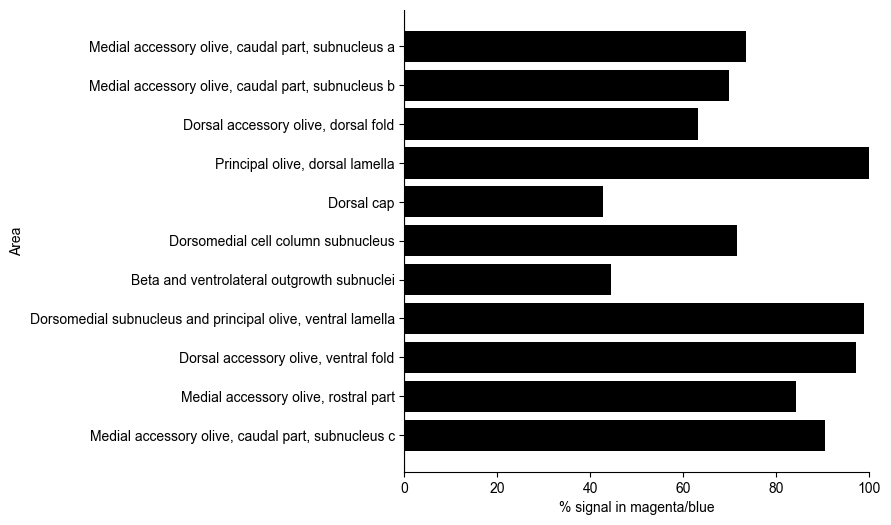

In [31]:
btp.density_map_corr_bar('r', False, (rg_di_areas, rg_di_title), sigma=0.5, value_norm='presynaptics', areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.density_map_corr_bar('r', False,  (rg_mi_areas, io_title), sigma=0.5, value_norm='within_region')
btp.density_map_corr_bar('r', True,  (rg_mi_areas, rg_mi_title), sigma=0.5, value_norm='within_region')
btp.density_map_corr_bar('r', True,  (ag_mi_areas, ag_mi_title), sigma=0.5, value_norm=None, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
btp.density_map_corr_bar('r', True,  (ag_mo_areas, ag_mo_title), sigma=0.5, value_norm=None)
btp.density_map_corr_bar('r', True,  (ag_do_areas, ag_do_title), sigma=0.5, value_norm=None, areas_to_combine=areas_to_combine_that_arent_present_by_default)

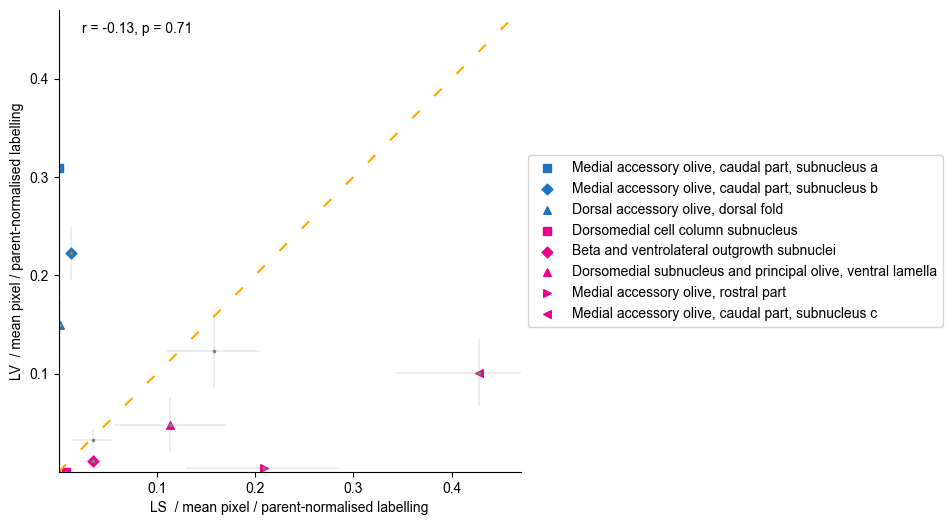

In [30]:
btp.area_selectivity_scatter('r', (rg_di_areas, rg_di_title), value_norm='presynaptics', custom_lim=None, fluorescence=False, log=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.area_selectivity_scatter('r', (rg_mi_areas, io_title), value_norm='within_region', custom_lim=None, fluorescence=False, log=False)
btp.area_selectivity_scatter('r', (rg_mi_areas, rg_mi_title), value_norm='within_region',custom_lim=None, fluorescence=True,  log=False)
btp.area_selectivity_scatter('r', (ag_mi_areas, ag_mi_title), value_norm=None,           custom_lim=None, fluorescence=True,  log=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
btp.area_selectivity_scatter('r', (ag_mo_areas, ag_mo_title), value_norm=None,           custom_lim=None, fluorescence=True,  log=False)
btp.area_selectivity_scatter('r', (ag_do_areas, ag_do_title), value_norm=None,           custom_lim=None, fluorescence=True,  log=True, areas_to_combine=areas_to_combine_that_arent_present_by_default)

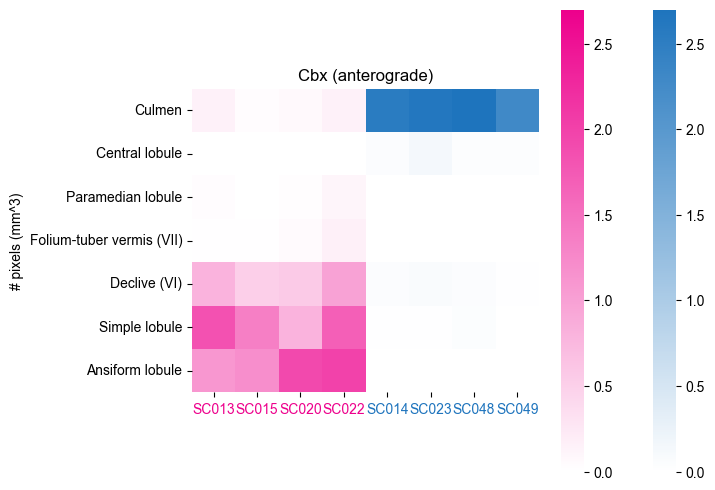

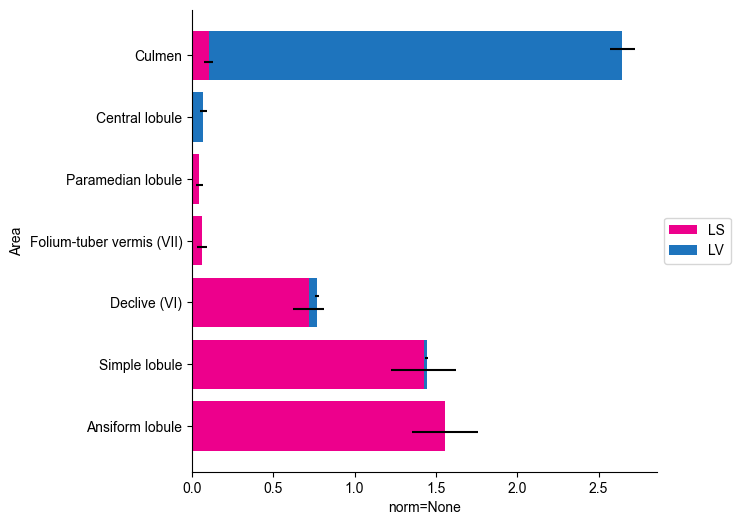

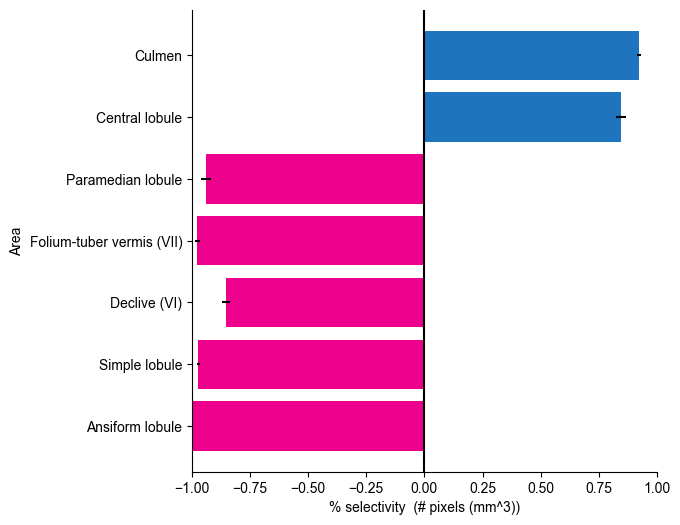

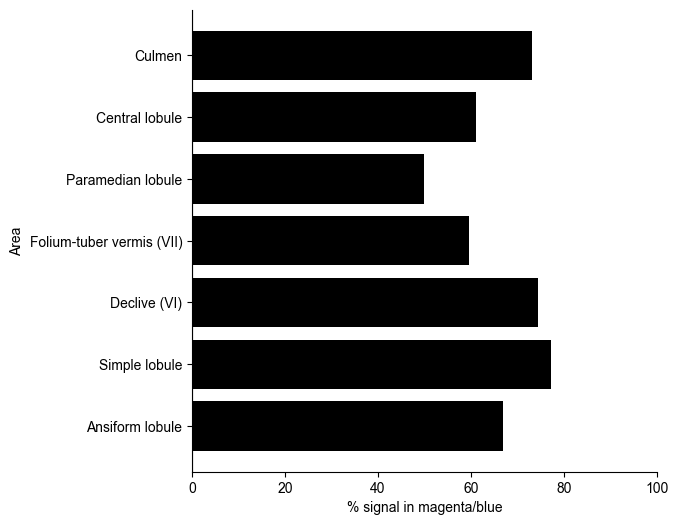

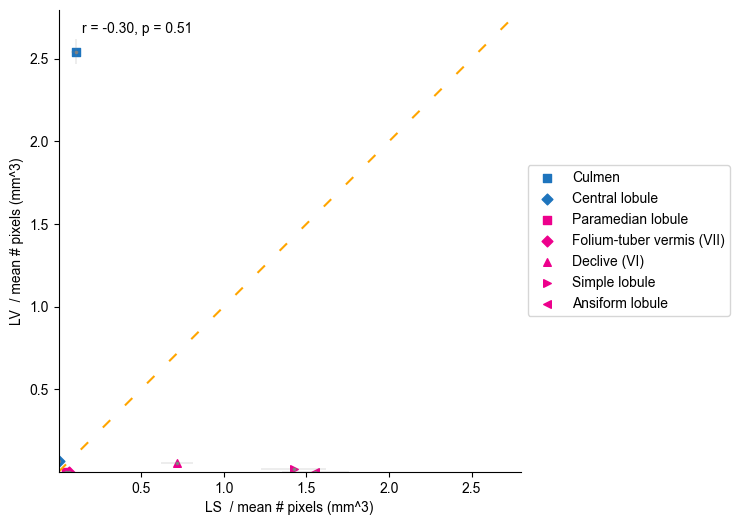

In [35]:
btp.region_signal_matrix('r', (ag_cb_areas, ag_cb_title), value_norm=None, figsize=(7,6), vmax=None, fluorescence=True, log_plot=False);
btp.area_total_signal_bar('r', (ag_cb_areas, ag_cb_title), value_norm=None, fluorescence=True)
btp.area_selectivity_with_errors('r', (ag_cb_areas, ag_cb_title), value_norm=None, fluorescence=True)
btp.density_map_corr_bar('r', True, (ag_cb_areas, ag_cb_title), sigma=0.5, value_norm=None)
btp.area_selectivity_scatter('r', (ag_cb_areas, ag_cb_title), value_norm=None, custom_lim=None, fluorescence=True, log=False)

## Heatmaps for Fig 3, 4, 6 and 7

['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']


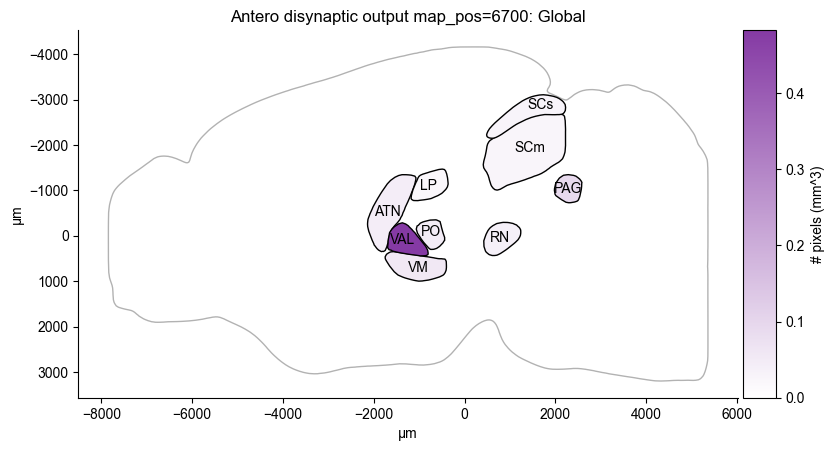

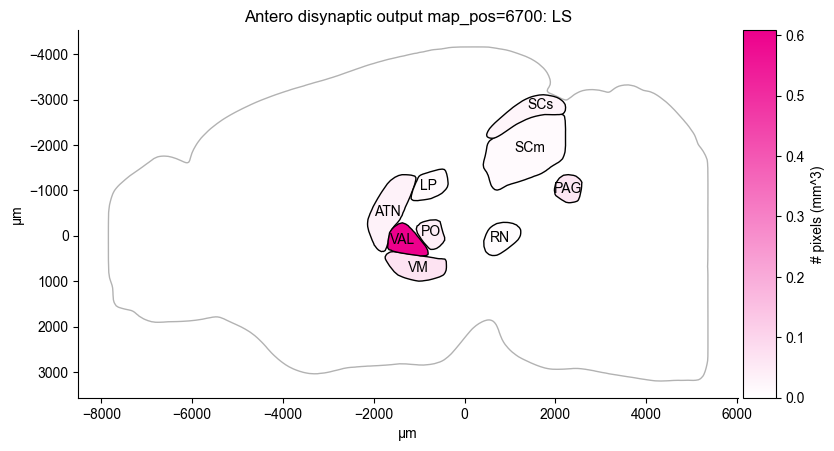

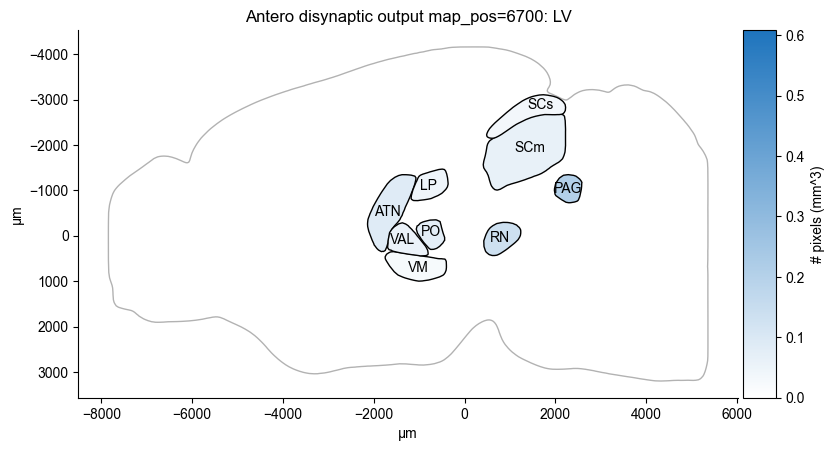

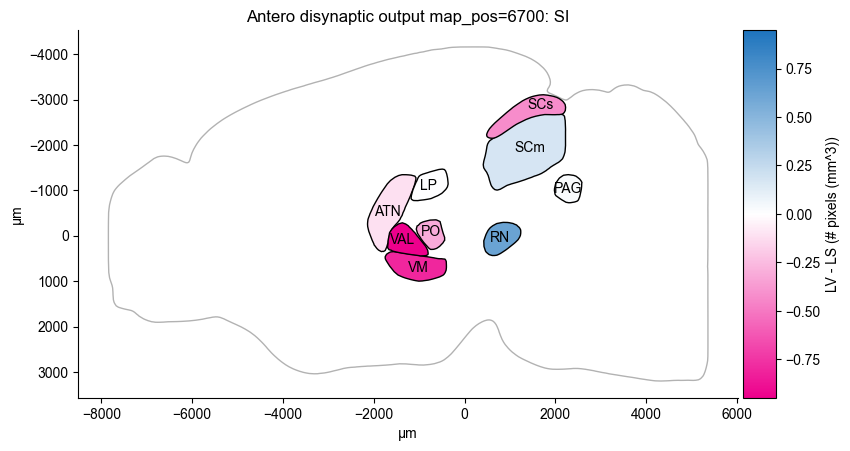

['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']


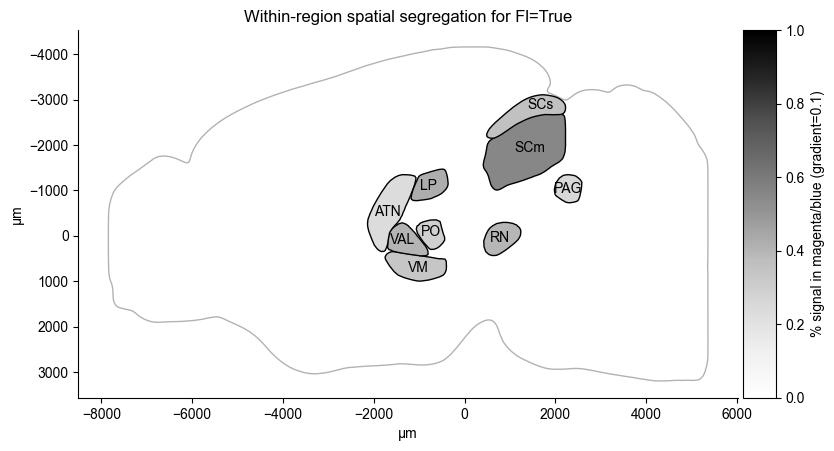

['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']


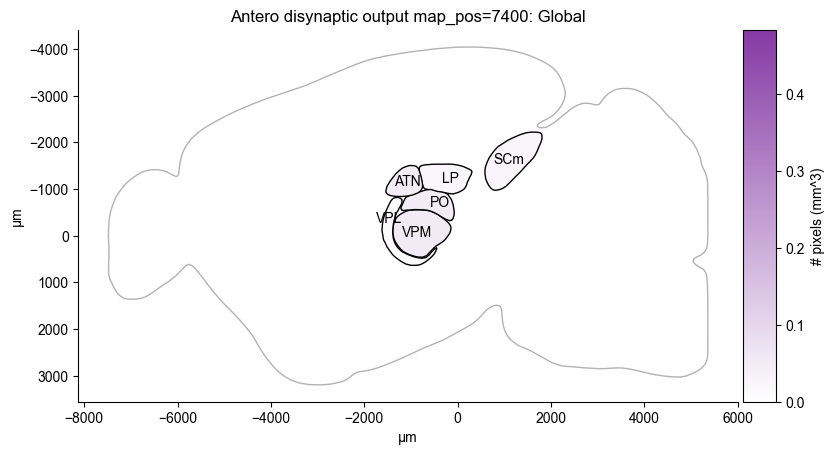

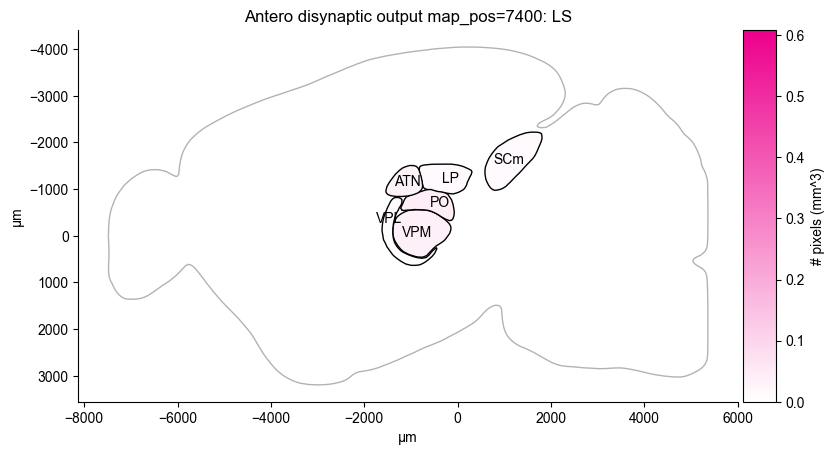

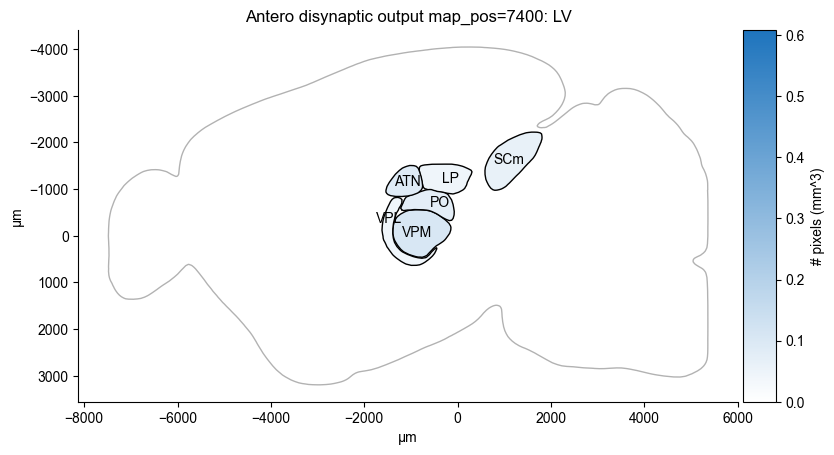

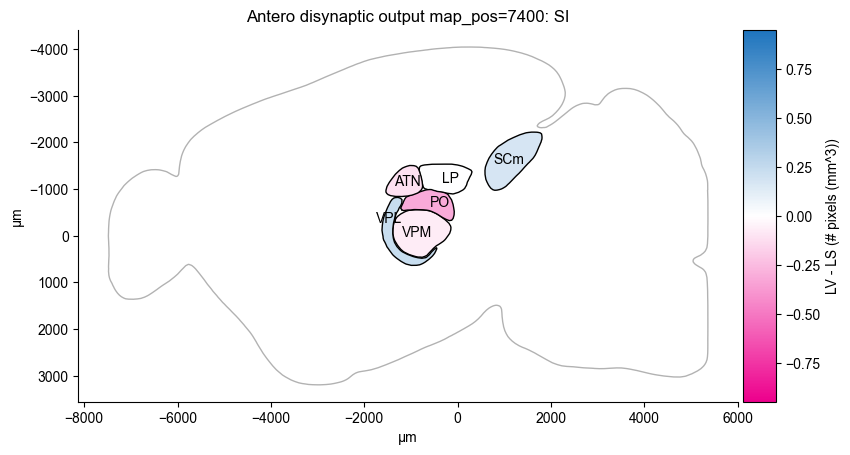

['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']


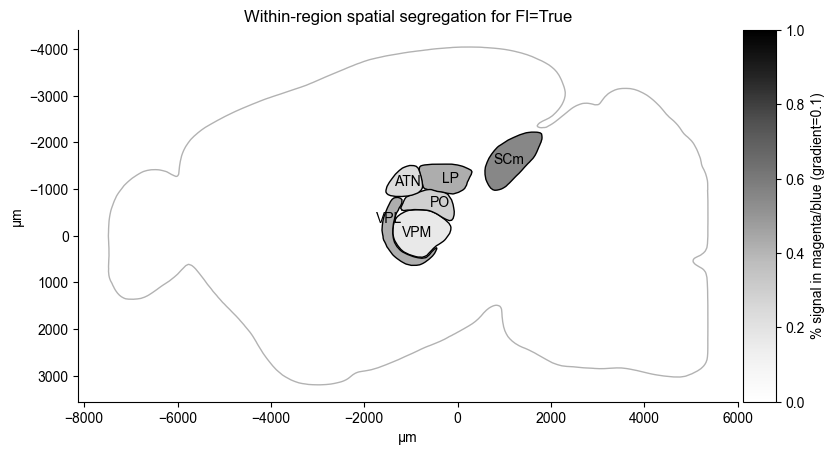

In [24]:
# allen atlas is 11400µm ML, 8000µm DV, 13200µm AP
#btp.generate_group_comparison_heatmaps('r', False, rg_di_areas, all_incf_title, norm='presynaptics', orientation='sagittal', pair_plot_vmax=None, spatialseg_vmax=1, position=6500, legend=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
#btp.generate_group_comparison_heatmaps('r', True,  ag_mi_areas, all_inmf_title, norm=None, orientation='sagittal', pair_plot_vmax=None, spatialseg_vmax=1, position=6500, legend=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
#btp.generate_group_comparison_heatmaps('r', True,  ag_mo_areas, all_otmo_title, norm=None, orientation='frontal',  pair_plot_vmax=None, spatialseg_vmax=1, position=11300, legend=False)
btp.generate_group_comparison_heatmaps('r', True,  ag_do_areas, all_otdi_title + '_pos=6700', norm=None, orientation='sagittal', pair_plot_vmax=None, spatialseg_vmax=1, position=6700, legend=False, areas_to_combine=areas_to_combine_that_arent_present_by_default)
btp.generate_group_comparison_heatmaps('r', True,  ag_do_areas, all_otdi_title + '_pos=7400', norm=None, orientation='sagittal', pair_plot_vmax=None, spatialseg_vmax=1, position=7400, legend=False, areas_to_combine=areas_to_combine_that_arent_present_by_default)

### Global selectivity and spatial congruence analysis

In [24]:
avgs_mi, corr_mi = btp.helpers.get_SI_and_corrs('r', (ag_mi_areas, ag_mi_title), True, sigma=0.5, norm=None, threshold=None, gradient=0.1, areas_to_combine=areas_to_combine_that_fix_atlas_issues)
avgs_mo, corr_mo = btp.helpers.get_SI_and_corrs('r', (ag_mo_areas, ag_mo_title), True, sigma=0.5, norm=None, threshold=None, gradient=0.1)
avgs_di, corr_di = btp.helpers.get_SI_and_corrs('r', (rg_di_areas, rg_di_title), False, sigma=0.5, norm='presynaptics', threshold=None, gradient=0.1, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
avgs_do, corr_do = btp.helpers.get_SI_and_corrs('r', (ag_do_areas, ag_do_title), True, sigma=0.5, norm=None, threshold=None, gradient=0.1, areas_to_combine=areas_to_combine_that_arent_present_by_default)

['Pontine reticular nucleus', 'Pontine reticular nucleus, caudal part']
['Spinal nucleus of the trigeminal, caudal part', 'Spinal nucleus of the trigeminal, interpolar part', 'Spinal nucleus of the trigeminal, oral part']
No data in this area. 0.0 total across all voxels.
['Pontine reticular nucleus', 'Pontine reticular nucleus, caudal part']
['Spinal nucleus of the trigeminal, caudal part', 'Spinal nucleus of the trigeminal, interpolar part', 'Spinal nucleus of the trigeminal, oral part']
['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']
['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']


### Continued

In [25]:
avgs_m = avgs_mi + avgs_mo
avgs_d = avgs_di + avgs_do
corr_m = corr_mi + corr_mo
corr_d = corr_di + corr_do

In [26]:
def lognorm(x, mu, sigma):
    return 1/(np.sqrt(2*np.pi)*sigma*x)*np.exp(-((np.log(x)- mu)**2)/(2*sigma**2))

In [27]:
def min_function(params, x, y):
    model = lognorm(x, *params)
    residual = ((y - model) ** 2).sum()
    return residual

In [28]:
def plot_ks(title, dist1, dist2, x0, cumulative=False, isVertical=True, legend=True, ax=None):
    if ax is None:
        f, ax = plt.subplots(figsize=(8,5))
    #ax.set_title('KS Test')
    statistic, p = stats.kstest(dist1, dist2, alternative='two_sided')
    
    orientation = 'vertical' if isVertical else 'horizontal'
    
    ax.annotate(f's={statistic:.2g}, p={p:.2g}', xy=(.3,.7), xycoords="axes fraction")
    
    def add_cumulative_line(dist, colour, ax): # title_fit
        dist_len = len(dist)
        dist_sorted = sorted(dist)
        dist_sorted.insert(0, 0)
        line_y_coords = [idx / dist_len for idx, val in enumerate(dist_sorted)]
        x, y = dist_sorted, line_y_coords
        if not isVertical:
            x, y = y, x
        ax.plot(x, y, color=colour) # , label=f"{title_fit}"
        ax.set_ylabel('Frequency')
        ax.set_xlabel(title)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1);
    
    def add_lognorm_fit(dist, colour, ax): # title_fit
        orientation = 'vertical' if isVertical else 'horizontal'
        y_vals, _, _ = ax.hist(dist, color=colour, alpha=0.5, bins=bins, orientation=orientation); # , label=f"{title_fit}"
        x_dummy = np.linspace(-0.5, 1.5, 10_000)
        x_vals = bin_centres
        
        res = minimize(min_function, x0=x0, args=(x_vals, y_vals))
        print(f'{res.message} (After {res.nit} iterations.)')
        
        x = x_dummy
        y = lognorm(x_dummy, *res.x)
        if not isVertical:
            x, y = y, x
        ax.plot(x, y, color=colour, label=f'Lognorm: func={res.fun:.2g}')
        
        if isVertical:
            ax.set_ylabel('Frequency')
            ax.set_xlabel(title)
            ax.set_xlim(-0.1, 1.1)
            ax.set_ylim(0, np.max(y_vals) * 1.25);
        else:
            ax.set_xlabel('Frequency')
            ax.set_ylabel(title)
            ax.set_ylim(-0.1, 1.1)
            ax.set_xlim(0, np.max(y_vals) * 1.25);
    
    if cumulative:
        add_cumulative_line(dist1, 'tab:orange', ax) # , title_m
        add_cumulative_line(dist2, 'tab:purple', ax) # , title_d
    else:
        add_lognorm_fit(dist1, 'tab:orange', ax) #, title_m
        add_lognorm_fit(dist2, 'tab:purple', ax) #, title_d
    if legend:
        ax.legend()
    
    #btf.save(f'ks_test_{title}', as_type='pdf')

### Fig 8

In [29]:
def si_vs_sd_scatter(title_1, title_2, plt_1_1, plt_1_2, plt_2_1, plt_2_2, si_1, si_2, sd_1, sd_2, x0, cumulative=False):
    f, axs = plt.subplots(2, 2, figsize=(10,10), width_ratios=[1,3], height_ratios=[3,1])
    axs[1,0].axis('off')
    plot_ks('', plt_1_1, plt_1_2, x0=x0, cumulative=cumulative, isVertical=False, legend=False, ax=axs[0,0]) # Spatial Selectivity
    plot_ks('', plt_2_1, plt_2_2, x0=x0, cumulative=cumulative, isVertical=True, legend=False, ax=axs[1,1]) # Lobule Selectivity
    axs[0,0].invert_xaxis()
    axs[1,1].invert_yaxis()
    axs[0,0].tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
    axs[1,1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[0,1].scatter(np.abs(si_1), sd_1, c='tab:orange', marker='^', label=title_1)
    axs[0,1].scatter(np.abs(si_2), sd_2, c='tab:purple', marker='^', label=title_2)
    #axs[0,1].scatter(np.abs(avgs_mo), corr_mo, c='tab:gray', marker='.', label='Monosynaptic outputs')
    #axs[0,1].scatter(np.abs(avgs_do), corr_do, c='tab:purple', marker='.', label='Disynaptic outputs')
    axs[0,1].set_title('SI vs SD')
    axs[0,1].set_xlabel('Selectivity Index')
    axs[0,1].set_ylabel('Spatial Dissimilarity')
    axs[0,1].legend()
    axs[0,1].grid()
    axs[0,1].set_xlim(-0.02, 1.02); axs[1,1].set_xlim(-0.02, 1.02)
    axs[0,1].set_ylim(-0.02, 1.02); axs[0,0].set_ylim(-0.02, 1.02)
    btf.save(f'SI_corrs_scatter_{title_1}_vs_{title_2}_cmltv={cumulative}', as_type='pdf')

In [30]:
# Only inputs
plot_mi_si, plot_di_si, plot_mi_sd, plot_di_sd = np.abs(np.nan_to_num(avgs_mi, nan=0)), np.abs(np.nan_to_num(avgs_di, nan=0)), np.abs(np.nan_to_num(corr_mi, nan=0)), np.abs(np.nan_to_num(corr_di, nan=0))
bins=np.histogram(np.hstack((plot_mi_si, plot_di_si, plot_mi_sd, plot_di_sd)), bins=25)[1]
bin_centres = 0.5 * (bins[1:] + bins[:-1])

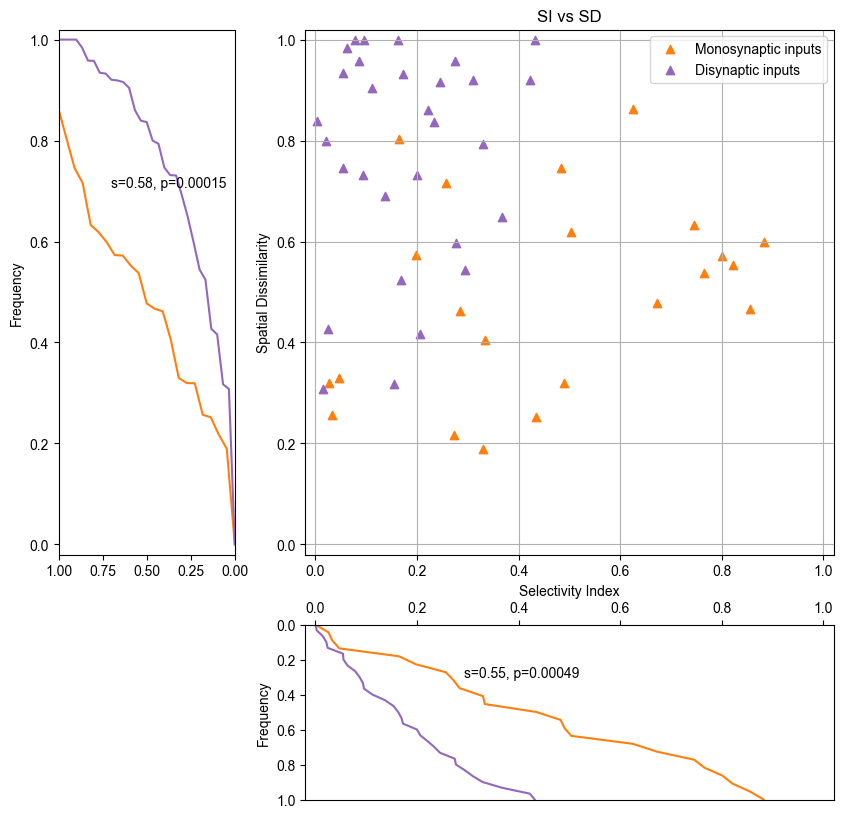

In [31]:
si_vs_sd_scatter('Monosynaptic inputs', 'Disynaptic inputs', plot_mi_sd, plot_di_sd, plot_mi_si, plot_di_si, avgs_mi, avgs_di, corr_mi, corr_di, x0=(0.8, 0.8), cumulative=True)

In [32]:
# Only outputs
plot_mo_si, plot_do_si, plot_mo_sd, plot_do_sd = np.abs(np.nan_to_num(avgs_mo, nan=0)), np.abs(np.nan_to_num(avgs_do, nan=0)), np.abs(np.nan_to_num(corr_mo, nan=0)), np.abs(np.nan_to_num(corr_do, nan=0))
bins=np.histogram(np.hstack((plot_mo_si, plot_do_si, plot_mo_sd, plot_do_sd)), bins=25)[1]
bin_centres = 0.5 * (bins[1:] + bins[:-1])

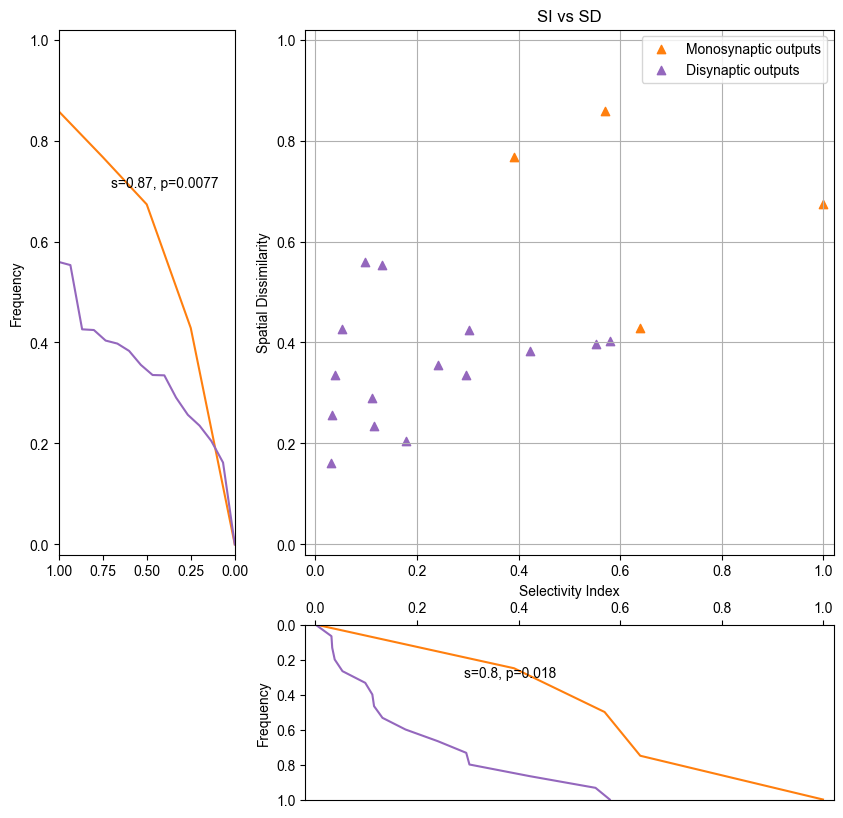

In [33]:
si_vs_sd_scatter('Monosynaptic outputs', 'Disynaptic outputs', plot_mo_sd, plot_do_sd, plot_mo_si, plot_do_si, avgs_mo, avgs_do, corr_mo, corr_do, x0=(0, 1), cumulative=True)

## Other paper plots

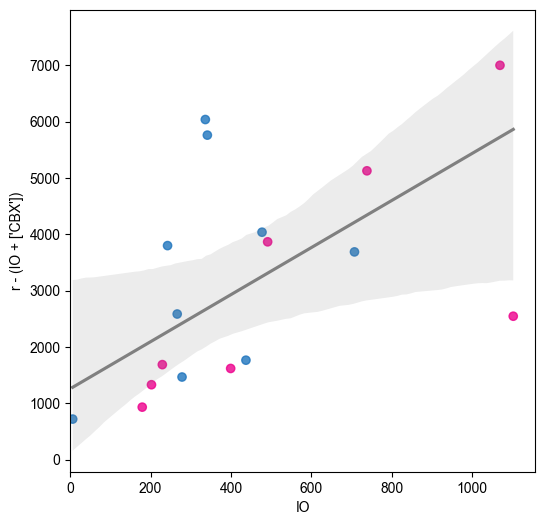

In [47]:
btp.region_comparison_scatter(False, 'prePost', set_postsyn_values_to_line=False, exclude_dataset_idx_from_line_fit=[], swap_axes=True, labels=False);

C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning

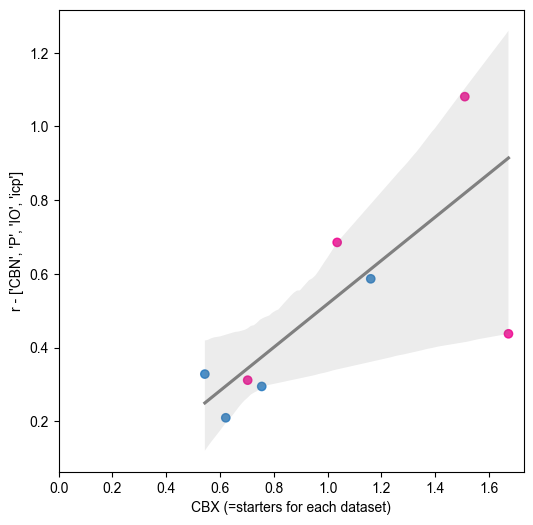

In [5]:
# make sure to set the exclude regions differently from the retro expts here!
btp.region_comparison_scatter(True, 'prePostAntero', set_postsyn_values_to_line=False, exclude_dataset_idx_from_line_fit=[], swap_axes=True, labels=False);

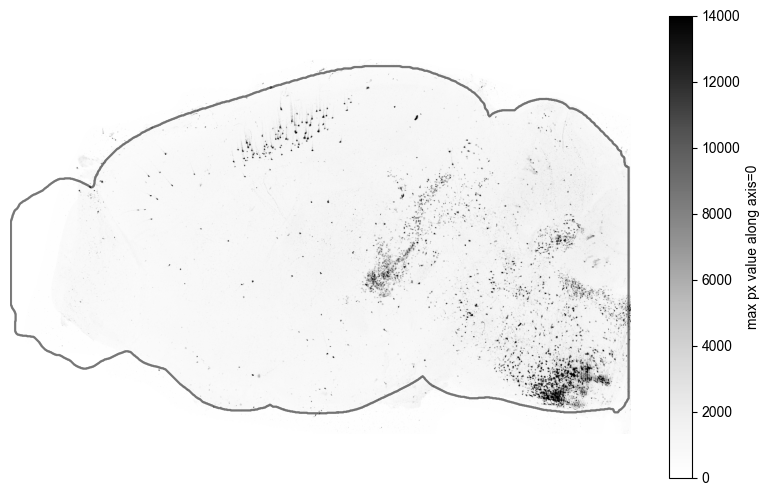

In [6]:
btp.project_raw_data('r', bt.datasets[16], axis=0, vmax=14_000, padding=None) # LV

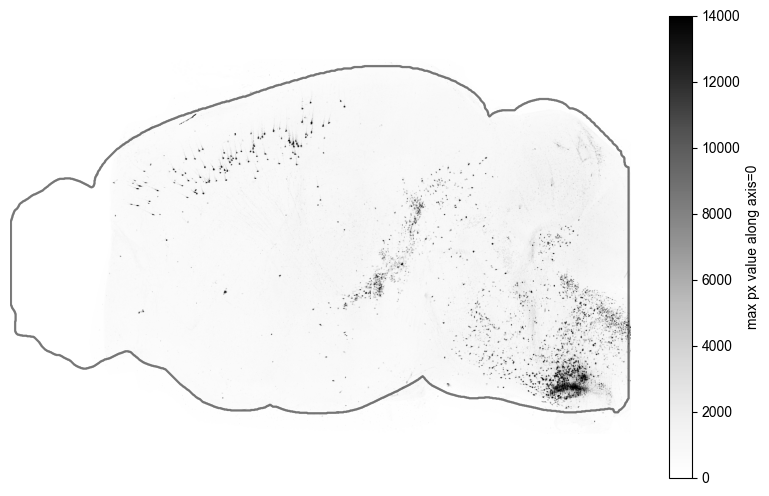

In [5]:
btp.project_raw_data('r', bt.datasets[7], axis=0, vmax=14_000, padding=None) # LS

## Crus I setup

In [13]:
bt.Dataset('SC037', 'CI', ['r']);
bt.Dataset('SC038', 'CI', ['r']);
bt.Dataset('SC039', 'CI', ['r']);
bt.Dataset('SC043', 'CI', ['r']);

In [14]:
btp.helpers.set_group_colours(group2='#FF9909')

In [15]:
rg_mi_areas, rg_mi_title = bta.inputs_antero_CF()
ci_mi_title = 'Crus I ' + rg_mi_title

# Crus I - IO

No data in this area. 0.0 total across all voxels.
No data in this area. 0.0 total across all voxels.
No data in this area. 0.0 total across all voxels.
No data in this area. 0.0 total across all voxels.
No data in this area. 0.0 total across all voxels.
No data in this area. 0.0 total across all voxels.


C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\braintracer\braintracer\plotting_helpers.py:314: RuntimeWarning: invalid value encountered in divide
  perc_deviation = ((LV_labelling - LS_labelling) / (LS_labelling + LV_labelling)) * 100


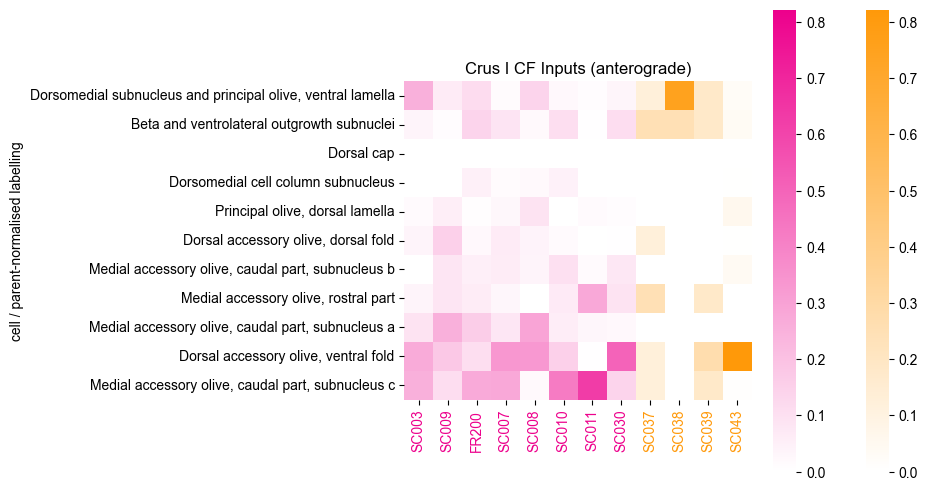

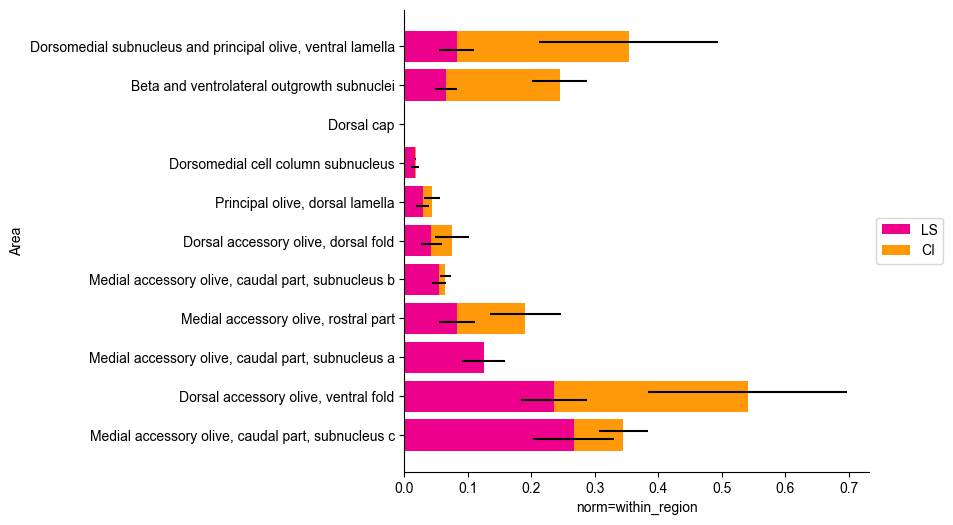

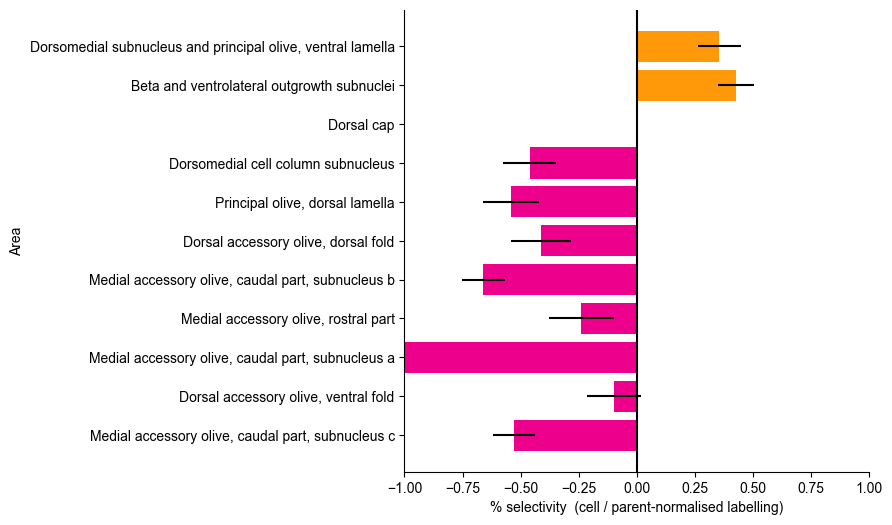

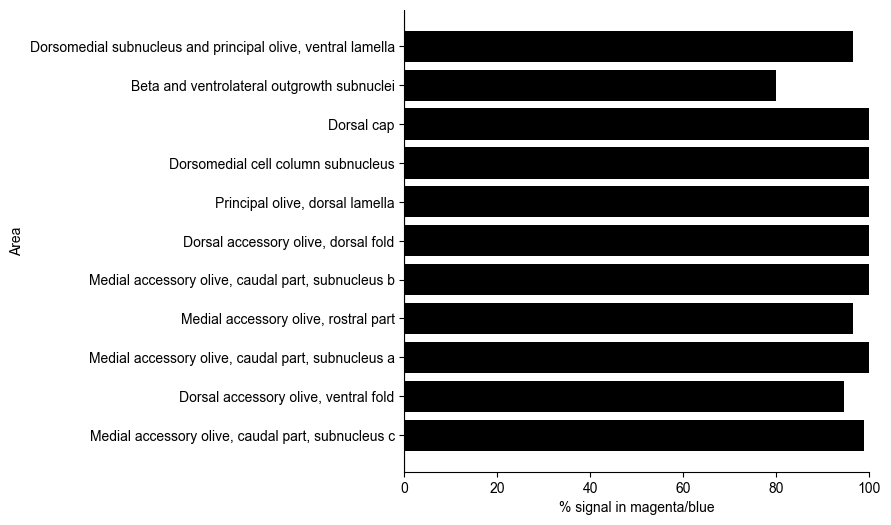

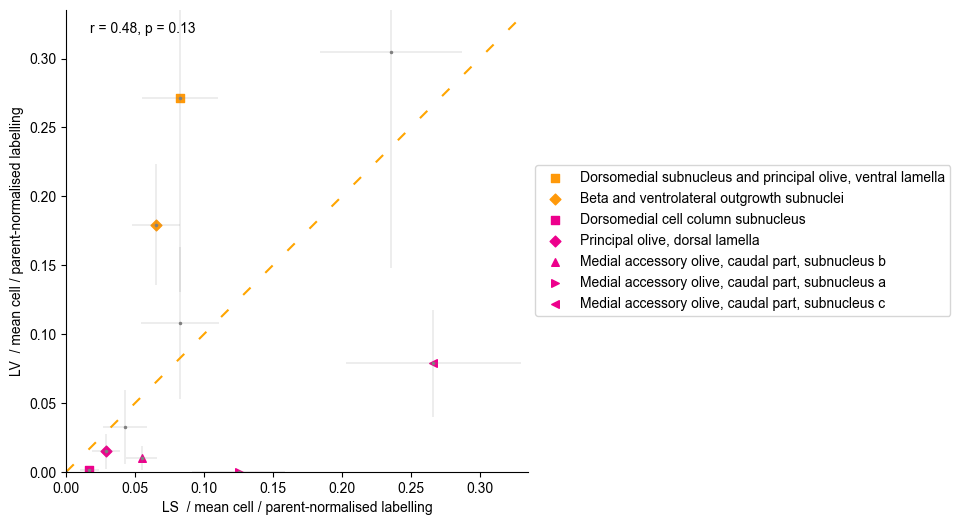

In [16]:
btp.region_signal_matrix('r', (rg_mi_areas, ci_mi_title), value_norm='within_region', figsize=(7,6), vmax=None, fluorescence=False, log_plot=False);
btp.area_total_signal_bar('r', (rg_mi_areas, ci_mi_title), value_norm='within_region', fluorescence=False)
btp.area_selectivity_with_errors('r', (rg_mi_areas, ci_mi_title), value_norm='within_region', fluorescence=False)
btp.density_map_corr_bar('r', False, (rg_mi_areas, ci_mi_title), sigma=0.5, value_norm='within_region')
btp.area_selectivity_scatter('r', (rg_mi_areas, ci_mi_title), value_norm='within_region', custom_lim=None, fluorescence=False, log=False)

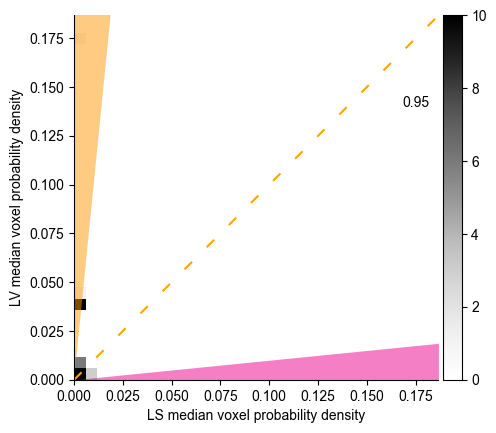

In [33]:
btp.pmap_corr_scatter_binned(('r', False, 83, 50, 0.5), gradient=0.1, vbounds=(0, 10))

Upper limit: 0.02379423031165953


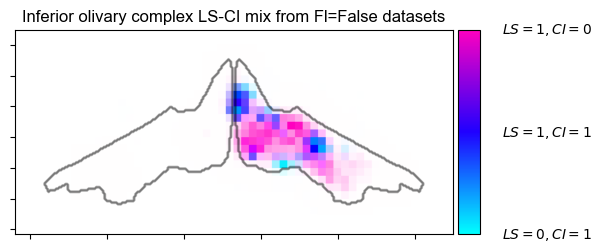

In [32]:
btp.probability_map_overlap('r', False, area_num=83, binsize=50, axis=2, sigma=0.5, subregions=None, projcol='k', padding=10, saturation_multiplier=3)

# Crus I - Disynaptic inputs

In [16]:
rg_di_areas, rg_di_title = get_di_input_areas()
ci_di_title = 'Crus I ' + rg_di_title

['Pontine reticular nucleus', 'Pontine reticular nucleus, caudal part']
['Spinal nucleus of the trigeminal, caudal part', 'Spinal nucleus of the trigeminal, interpolar part', 'Spinal nucleus of the trigeminal, oral part']
['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']
['Pontine reticular nucleus', 'Pontine reticular nucleus, caudal part']
['Spinal nucleus of the trigeminal, caudal part', 'Spinal nucleus of the trigeminal, interpolar part', 'Spinal nucleus of the trigeminal, oral part']
['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial accesory oculomotor nucleus', 'Mesodiencephalic junction']
['Pontine reticular nucleus', 'Pontine reticular nucleus, caudal part']
['Spinal nucleus of the trigeminal, caudal part', 'Spinal nucleus of the trigeminal, interpolar part', 'Spinal nucleus of the trigeminal, oral part']
['Interstitial nucleus of Cajal', 'Nucleus of Darkschewitsch', 'Medial acc

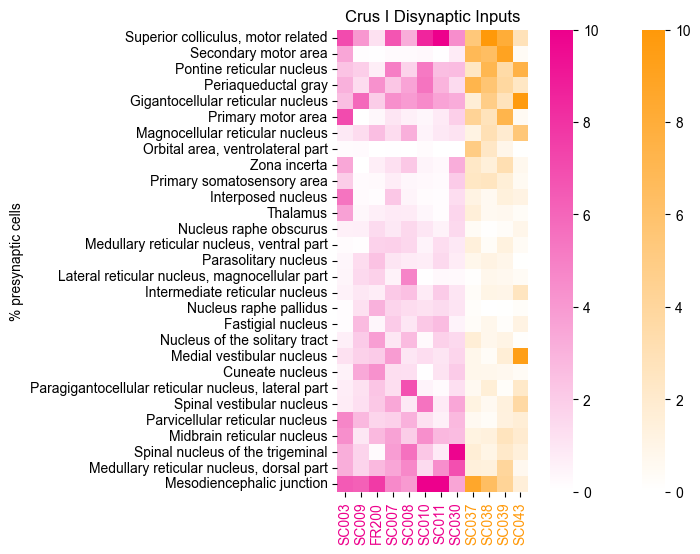

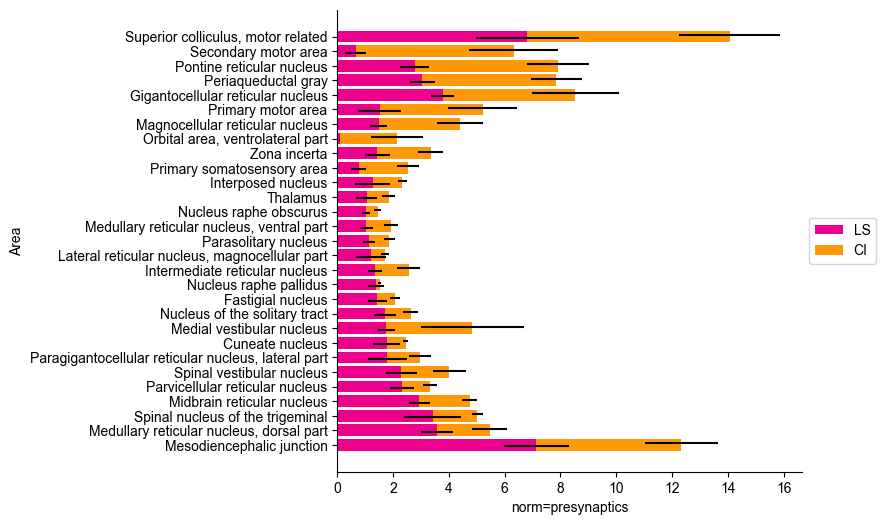

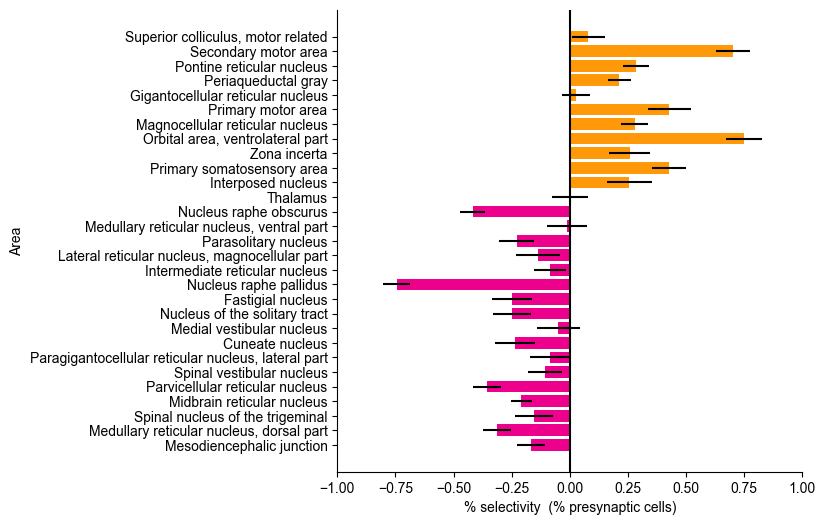

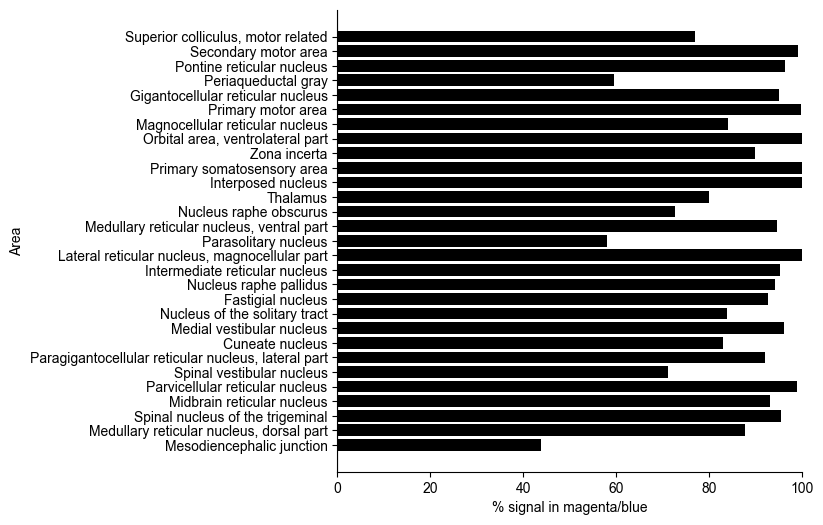

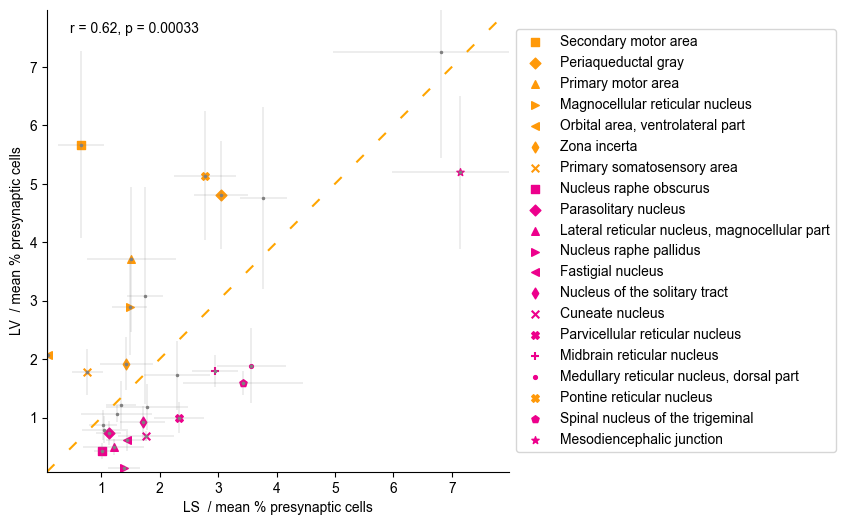

In [17]:
btp.region_signal_matrix('r', (rg_di_areas, ci_di_title), value_norm='presynaptics', figsize=(7,6), vmax=10, fluorescence=False, log_plot=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default);
btp.area_total_signal_bar('r', (rg_di_areas, ci_di_title), value_norm='presynaptics', fluorescence=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.area_selectivity_with_errors('r', (rg_di_areas, ci_di_title), value_norm='presynaptics', fluorescence=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.density_map_corr_bar('r', False, (rg_di_areas, ci_di_title), sigma=0.5, value_norm='presynaptics', areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)
btp.area_selectivity_scatter('r', (rg_di_areas, ci_di_title), value_norm='presynaptics', custom_lim=None, fluorescence=False, log=False, areas_to_combine=areas_to_combine_that_fix_atlas_issues_and_arent_present_by_default)

No data in this area. 0.0 total across all voxels.
Upper limit: 0.011218216219114603


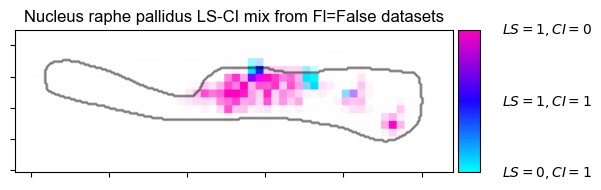

In [24]:
btp.probability_map_overlap('r', False, area_num=230, binsize=50, axis=0, sigma=0.5, subregions=None, projcol='k', padding=10, saturation_multiplier=3)

KeyboardInterrupt: 

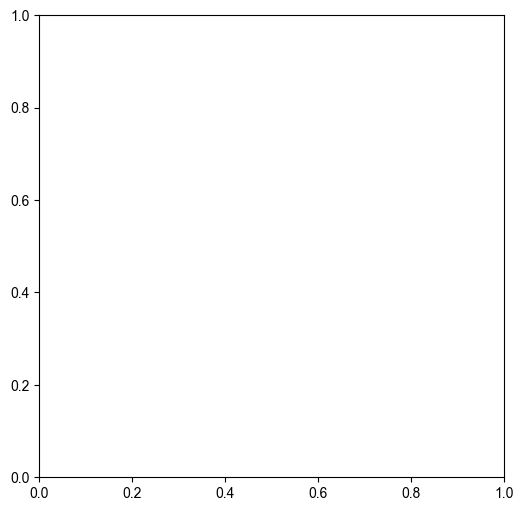

In [25]:
btp.probability_map_overlap('r', False, area_num=500, binsize=50, axis=0, sigma=0.5, subregions=None, projcol='k', padding=10, saturation_multiplier=3)

In [ ]:
btp.probability_map_overlap('r', False, area_num=714, binsize=50, axis=0, sigma=0.5, subregions=None, projcol='k', padding=10, saturation_multiplier=3)

In [ ]:
btp.probability_map_overlap('r', False, area_num=795, binsize=50, axis=2, sigma=0.5, subregions=[549009211], projcol='k', padding=10, saturation_multiplier=3)

# Below: Things that are supposed to be generalised

## Image Stack Functions

In [7]:
bt.datasets[0].show_coronal_section(slice_frac=(5,2751), cells_pm=5)
#btf.save('FR210_coronal_section', as_type='png')

TypeError: Dataset.show_coronal_section() got an unexpected keyword argument 'slice_frac'

(0.0, 1319.0) (0.0, 799.0)


((365, 145, 823), (775, 340, 1023))

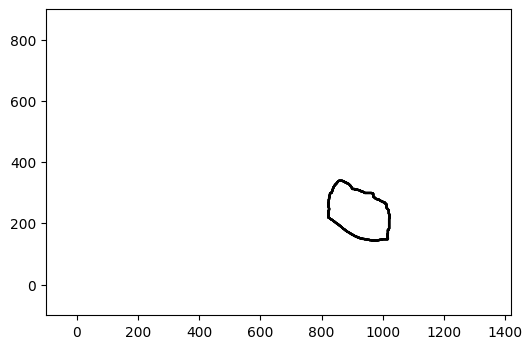

In [14]:
f, ax = plt.subplots(figsize=(6,6))
btp.plot_projection(ax, 294, padding=100, axis=2)

(np.float64(0.0), np.float64(1319.0)) (np.float64(0.0), np.float64(799.0))


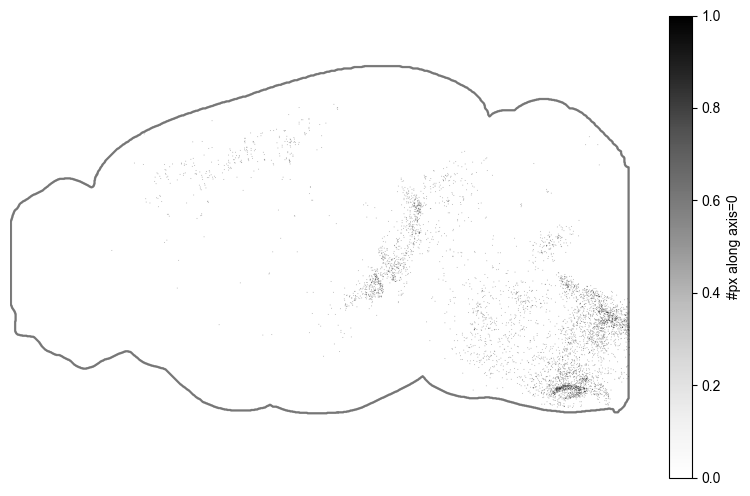

In [5]:
btp.project_cell_coords('r', bt.datasets[15], axis=0, vmax=1, padding=None)

(np.float64(0.0), np.float64(1319.0)) (np.float64(0.0), np.float64(799.0))


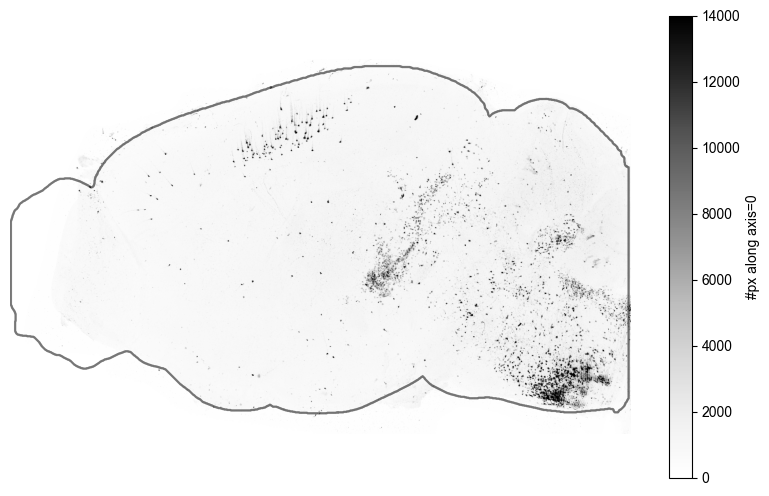

In [6]:
btp.project_raw_data('r', bt.datasets[16], axis=0, vmax=14_000, padding=None)

## 3D Spatial Binning

In [13]:
# IO: [8, 10, 12, 9, 16, 15, 0, 7, 5, 6, 13, 2, 3, 11, 4, 1, 14]
btp.bin_3D_matrix(83, binsize=100, aspect='auto', vbounds=(0,1), sigma=2, threshold=0, cmap='gray', order_method='average', blind_order=True, covmat=True, figsize=(20,7))

TypeError: 'dict' object is not callable

meta NOT subset; don't know how to subset; dropped


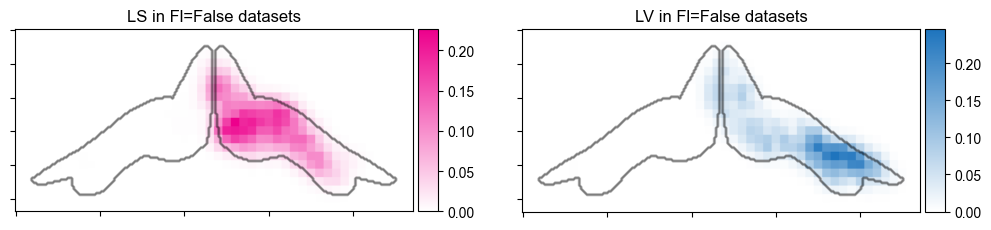

In [6]:
btp.probability_map('r', False, area_num=83, binsize=50, axis=2, sigma=1, subregions=None, projcol='k', padding=10)
# Axis: coronal (2), horizontal (1), or sagittal (0)

Bins of last dataset: (115, 81, 133), average number of bins containing cells: 28.11764705882353
604065 voxels removed by threshold=0, unless showing correlation matrix.


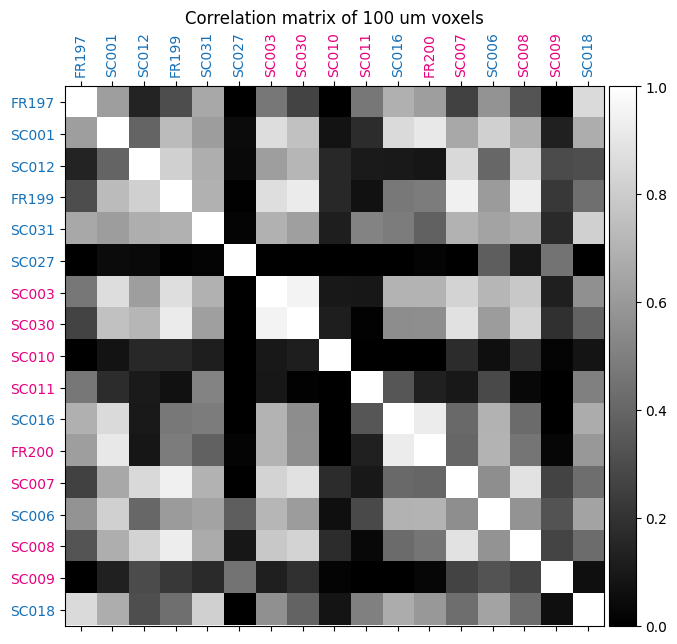

In [9]:
btp.bin_3D_matrix(549, binsize=100, aspect='auto', vbounds=(0,1), sigma=2, threshold=0, cmap='gray', order_method='average', blind_order=True, override_order=[8, 10, 12, 9, 16, 15, 0, 7, 5, 6, 13, 2, 3, 11, 4, 1, 14], covmat=True, figsize=(20,7))
# BIN INTO VOXELS
# this function is slightly complicated because it can make multiple different plots
# count matrix: covmat=False. only need aspect, vbounds, threshold, cmap, and figsize.
# correlation matrix: covmat=True. set area_num to correlate one region, None for whole brain. Sorting: set order_method e.g. 'average', set blind_order to determine if supervised with site label, set override_order to order by another matrix's order regardless of other sorting parameters

All areas: [1129, 313, 688, 354, 771, 1097, 549, 323, 379, 370, 386, 1117, 987, 290, 128, 795, 294, 230, 1048, 136, 235, 307, 395, 938, 852, 701, 720, 651, 437, 146, 1093, 797, 10, 17, 500, 453, 955, 1098, 1107, 978, 202, 225, 711, 985]
Area 1129 contains: [1097, 549, 290, 797]
Area 313 contains: [323, 128, 795, 294, 10, 17]
Area 688 contains: [500, 453, 985]
Area 354 contains: [379, 370, 386, 230, 1048, 136, 235, 307, 395, 938, 852, 701, 720, 651, 437, 955, 1098, 1107, 978, 202, 225, 711]
Area 771 contains: [1117, 987, 146, 1093]


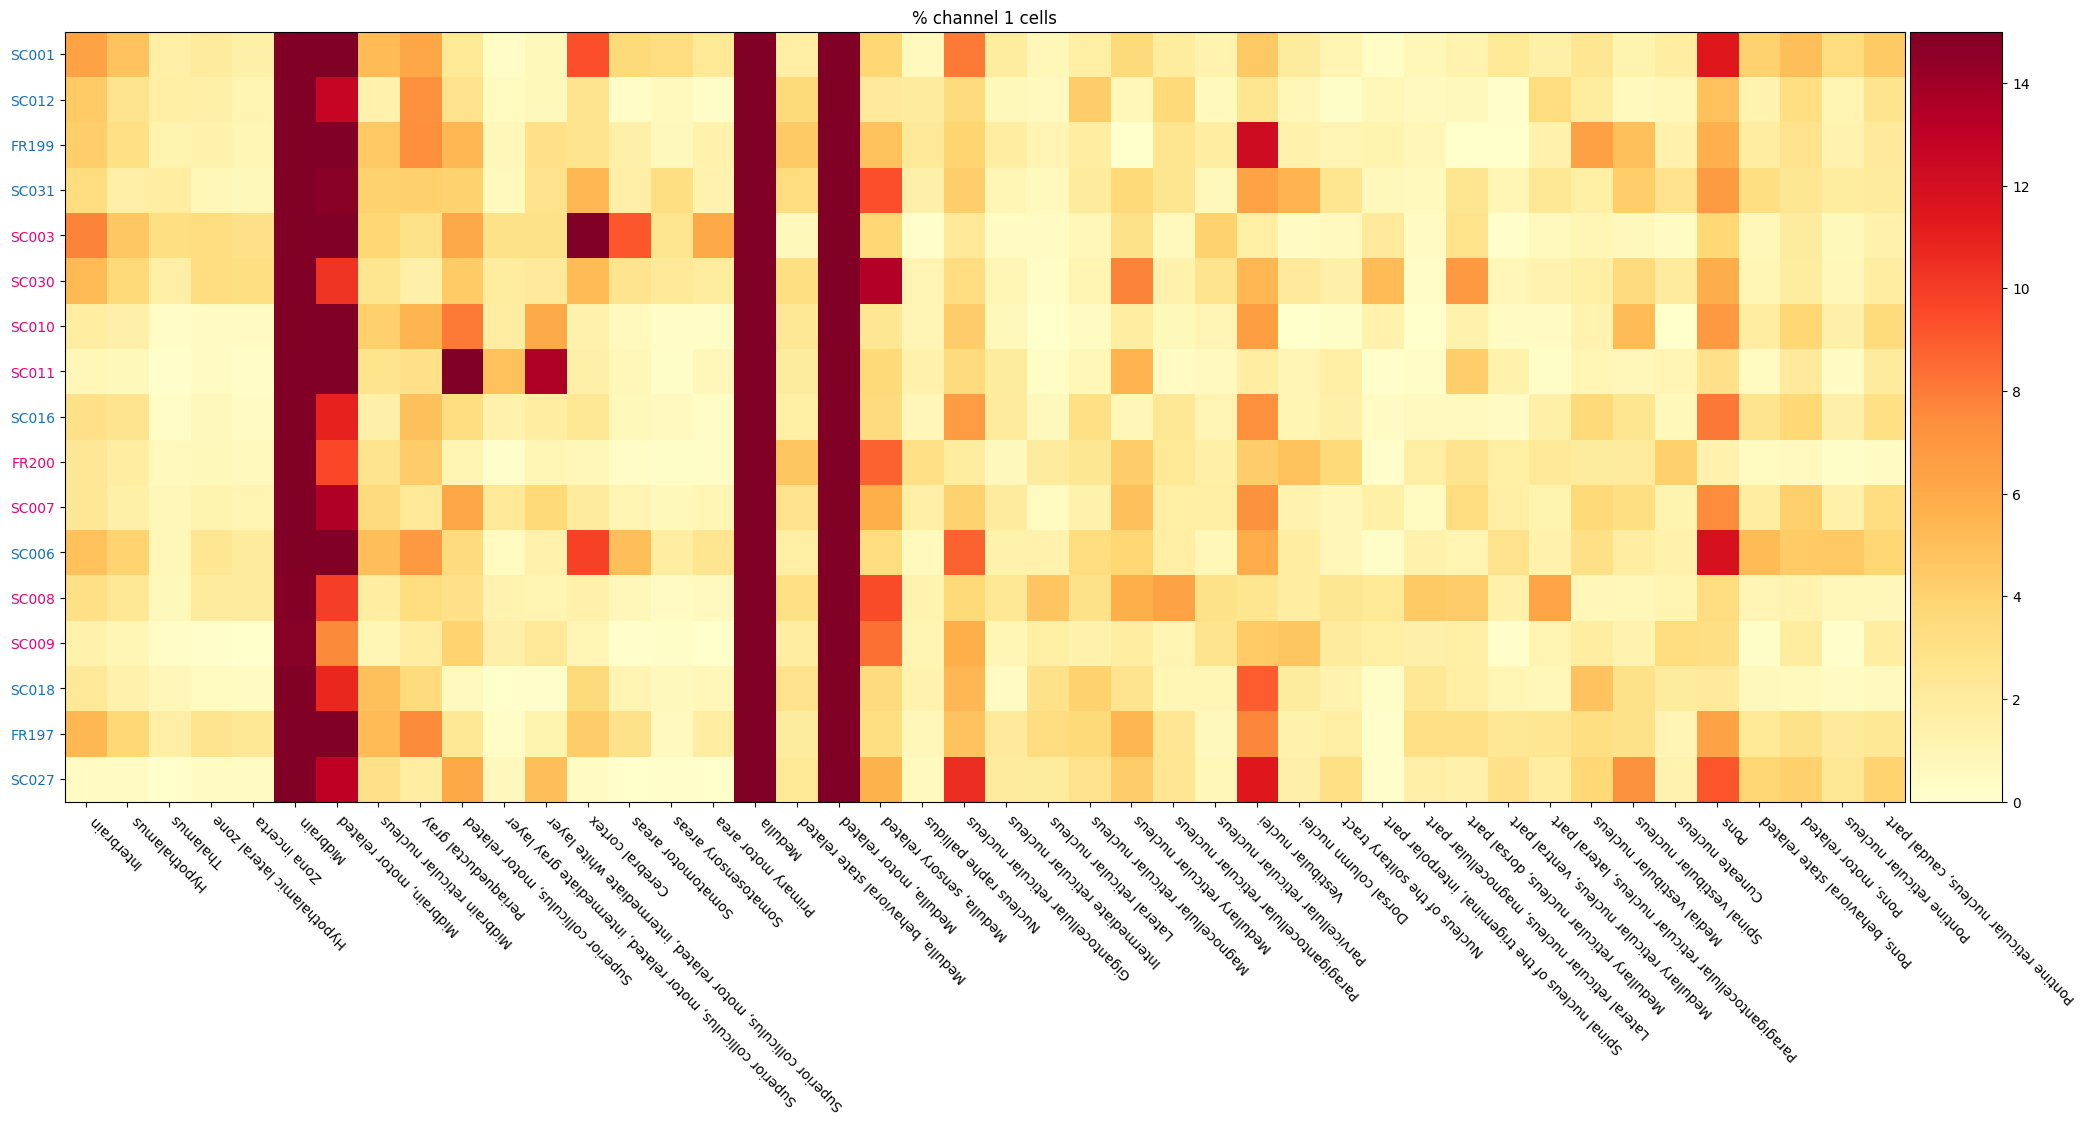

In [4]:
parent, children = bt.children_from('CB', depth=0)
children = np.array(children)
children = np.append(children, [512, 8, 1009, 960, 728, 83]) # big areas + IO
children = np.append(children, [567, 695, 315]) # duplicate cerebral cortex regions
children = np.append(children, [343, 1065]) # remove areas that inherit everything, e.g. brainstem

btp.generate_matrix_plot(threshold=1, ignore=children, vbounds=(0,15), normalisation='ch1', override_order=[10, 12, 9, 16, 0, 7, 5, 6, 13, 2, 3, 11, 4, 1, 14, 8, 15], covmat=False, rowvar=1, zscore=False, cmap='YlOrRd', figsize=(25,10), aspect='auto')
#btf.save('matrix_whole_brain_areas_unsupervised', as_type='pdf')
# BIN INTO REGIONS
# count matrix: covmat=False. threshold selects regions by minimum, ignore=[] regions to exclude, normalisation ['postsynaptics':per starter, 'ch1':% all, None:#cells], rowvar selects variable on x/y axis
# correlation matrix: covmat=True.

## General Functions

In [1]:
bt.get_area_info(['IO'], bt.datasets[0], 'r')
# get information about an individual region

NameError: name 'bt' is not defined

In [5]:
bt.datasets[0].num_cells(ch1=True)
# total cells in a dataset

1955

In [7]:
sum_cells = 0
for dataset in bt.datasets:
    sum_cells = sum_cells + bt.get_area_info(519, dataset.ch1_cells_by_area)[2][0]
    print(bt.get_area_info('CBN', dataset.ch1_cells_by_area)[2][0])
sum_cells / len(bt.datasets)
# mean number of cells in an area

109
28
12
11
119
47
53
315
63
40
37
29
75
15
56
101
234


79.05882352941177

View results in braintracer/TRIO.


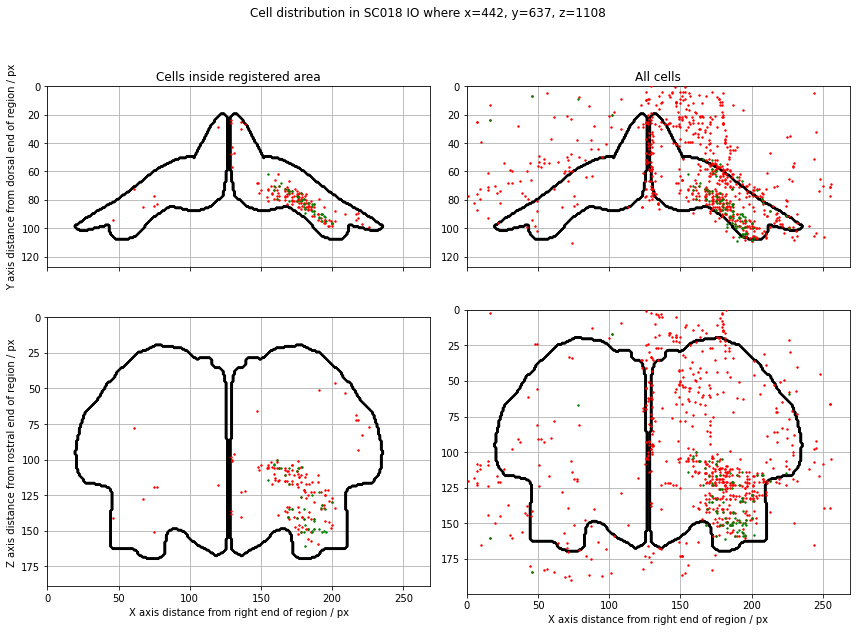

In [4]:
btp._generate_starter_validation_plot(padding=20)
# confirm where cell detections are in the starter region of each imported dataset

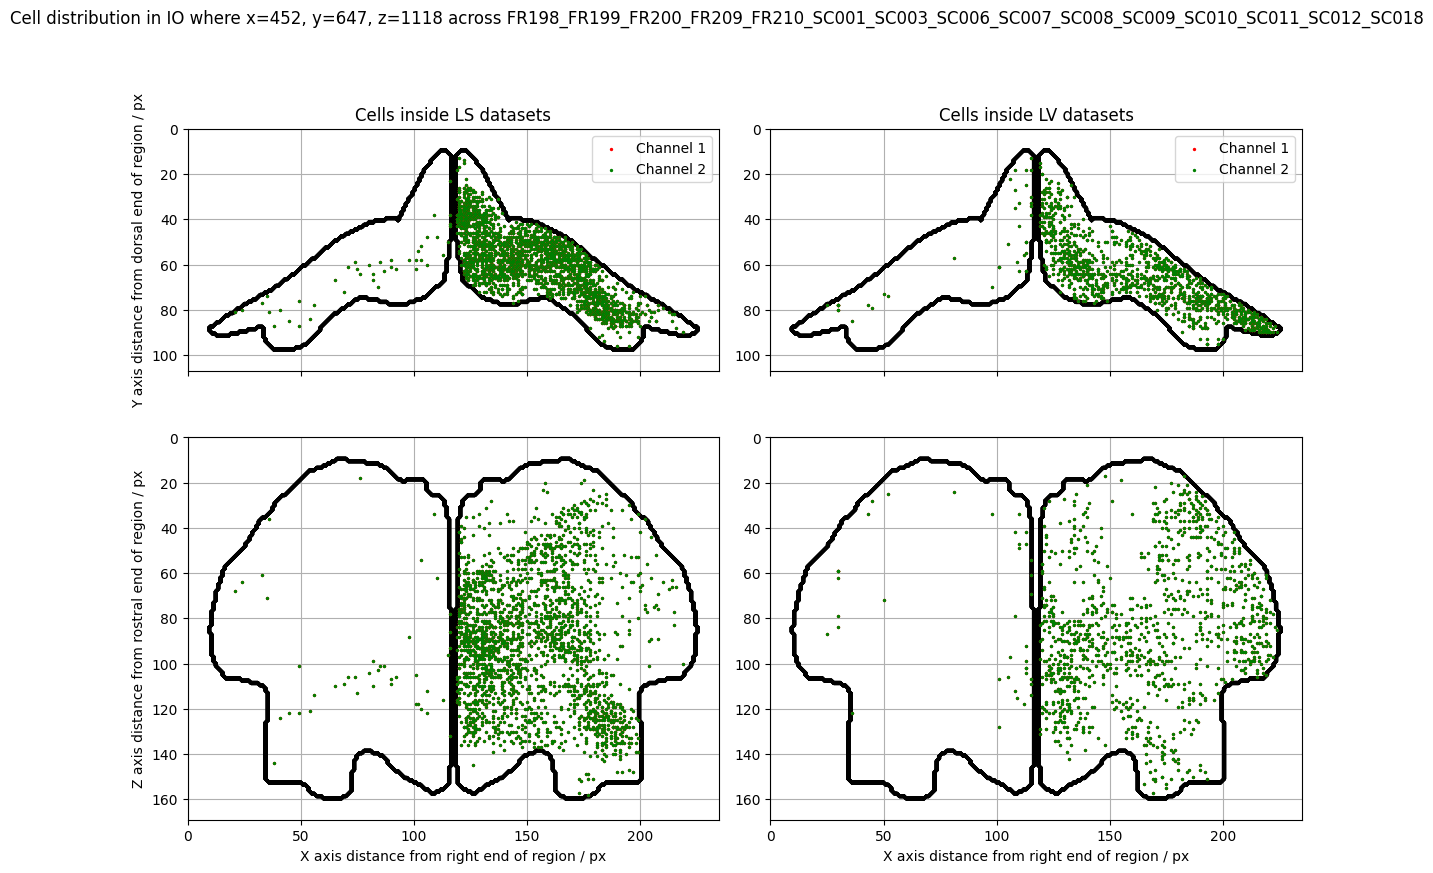

In [35]:
btp.generate_projection_plot('IO')
#btf.save(f'IO_projection_{title}', as_type='png')
# plot all cell coordinates by group in area

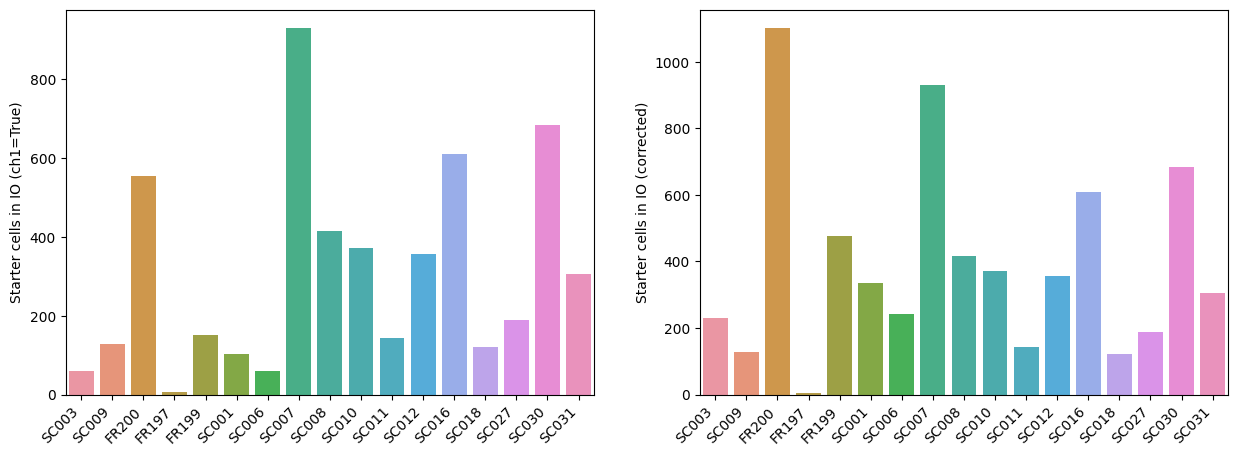

In [4]:
f, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))
f.set_facecolor('white')
btp.generate_starter_cell_plot(ax=ax1, true_only=True)
btp.generate_starter_cell_plot(ax=ax2)
# plot the number of starter cells across datasets

meta NOT subset; don't know how to subset; dropped


2.6985516436484285+-(1.5837971123498038)


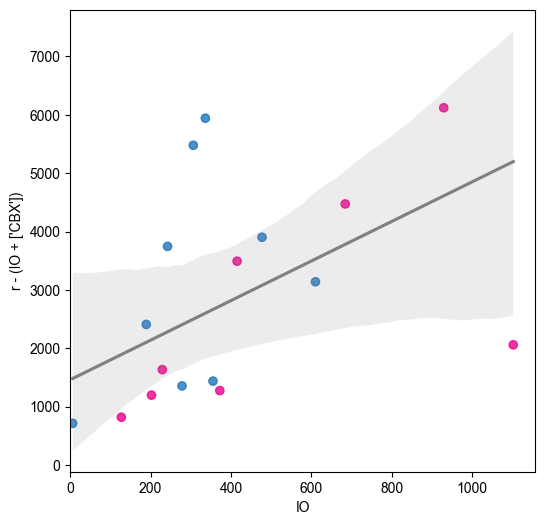

In [8]:
x_vals, y_vals = btp.region_comparison_scatter(False, 'prePost', set_postsyn_values_to_line=False, exclude_dataset_idx_from_line_fit=[], swap_axes=True)

# calculate the gradient with 95% CI
slope, intercept, r, p, std_err = stats.linregress(x_vals, y_vals)
n = len(x_vals)
dof = n - 2
t = stats.t.ppf(0.975, dof)
ci = t * std_err / 2
print(f"{slope}+-({ci})")

def add_origin_anchored_fit(x_vals, y_vals):
    X = x_vals[:, np.newaxis]**np.arange(1, 2)
    slope, *_ = np.linalg.lstsq(X, y_vals, rcond=None)[0]
    y_pred = slope * x_vals
    residuals = y_vals - y_pred
    n = len(x_vals)
    std_err = np.sqrt(np.sum(residuals**2) / (n - 1) / np.sum(x_vals**2))
    dof = n - 2
    t = stats.t.ppf(0.975, dof)
    ci = t * std_err
    print(f"{slope}+-({ci})")
    plt.plot(x_vals, y_pred);

C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\btenv\Lib\site-packages\statsmodels\robust\robust_linear_model.py:289: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'


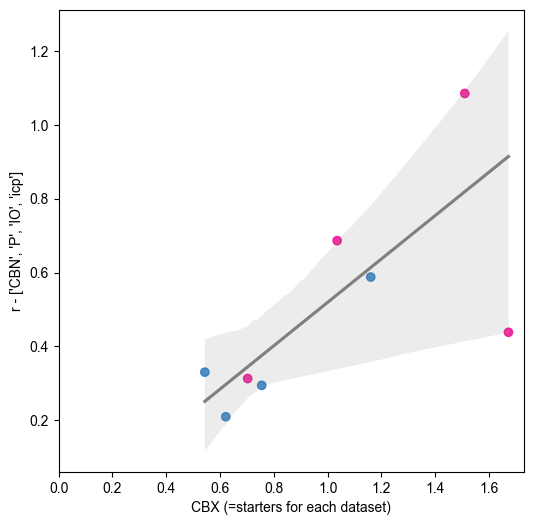

In [15]:
# IMPORTANT: this function corrects extreme starter cell counts FOR DOWNSTREAM ANALYSIS when set_postsyn_values_to_line=True
btp.region_comparison_scatter(True, 'prePostAntero', set_postsyn_values_to_line=False, exclude_dataset_idx_from_line_fit=[], swap_axes=True, labels=False);

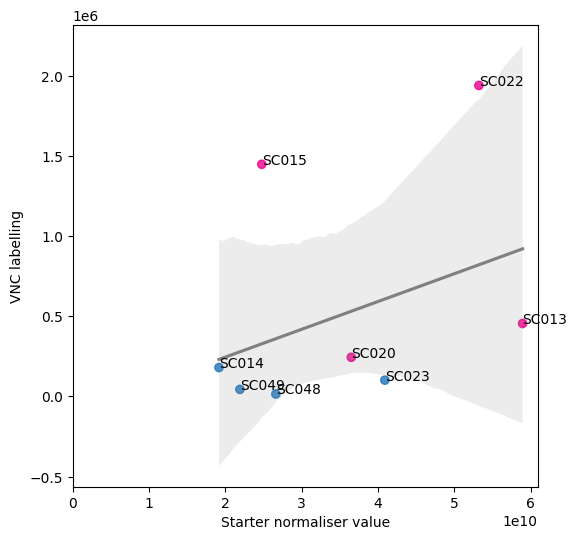

In [97]:
#areas = ['IO', 'CBN', 'P', 'VNC']
#for area in areas:
region_comparison_scatter(True, 'areaStarterNorm', areas=['IO'])

C:\Users\Sam\miniconda3\envs\bt\lib\site-packages\statsmodels\robust\robust_linear_model.py:288: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\bt\lib\site-packages\statsmodels\robust\robust_linear_model.py:288: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\bt\lib\site-packages\statsmodels\robust\robust_linear_model.py:288: ConvergenceWarning: Estimated scale is 0.0 indicating that the most last iteration produced a perfect fit of the weighted data.
  warnings.warn('Estimated scale is 0.0 indicating that the most'
C:\Users\Sam\miniconda3\envs\bt\lib\site-packages\statsmodels\robust\robust_linear_model.py:288: ConvergenceWarning: Estimated 

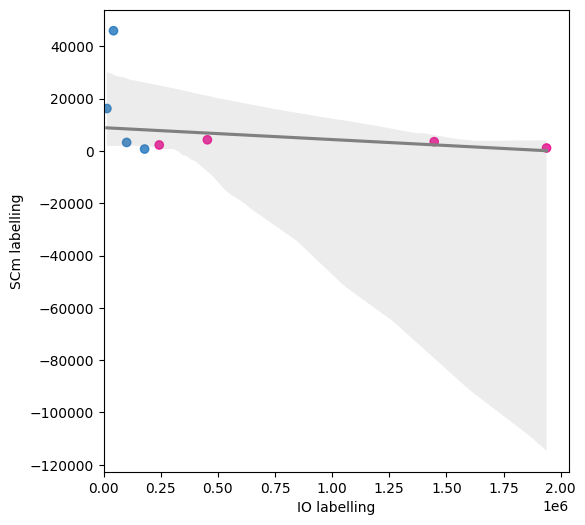

In [87]:
region_comparison_scatter(True, areas=['IO', 'SCm'])

## Cell Positions

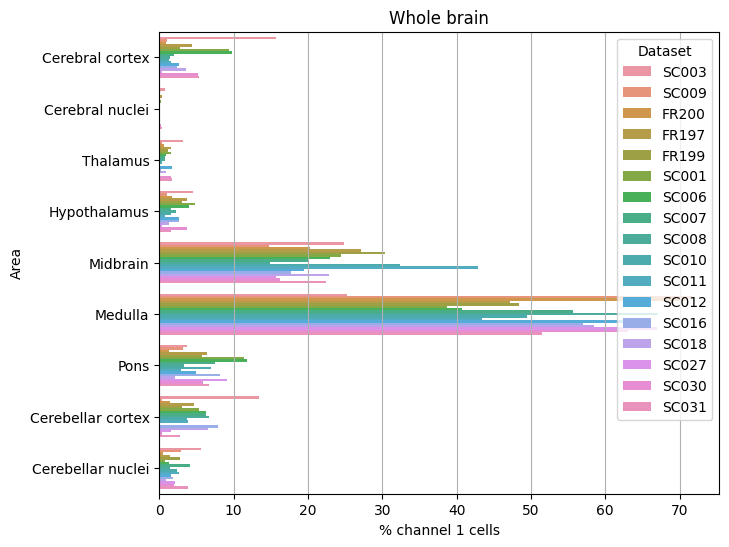

In [5]:
btp.generate_summary_plot()

In [5]:
# AREA SELECTIONS TO CHOOSE FROM
sfn_areas = ['MDRN','SCm','MRN','GRN','MARN','PRNr','VTA','PAG','P']
reward = ['ORB','VTA','STRv','SNc','ACB','CS','ACA','BLA','CEA','LHA']
motor = ['MO','MOp','MOs','STRd','VAL','VENT','GPi','SNr','SCm','MY-mot','MBmot','P-mot','DORsm','ILA','PL']
sensory = ['SS','SSp','SSp-ll','SSp-ul','SSs','MY-sen','MBsen','P-sen','PSV','SCs','DORsm']
other = ['FN','IP','DN','RAmb','RM','RO','RPA','RPO','CS','LC','STN','PAG','SPFm','POL','VM','LAT','ZI']
plot1 = ['SS','MO','PAG']
motor2 = ['MOs','PAG','MRN','GRN','SCm']
basal_ganglia = ['GPi','SNr','ACB','SNc','VTA','STRv']
uchida = ['VNC','IO','GRN','MRN','DCN','STRv']
cb_interesting1 = oof = ['SPF','LHA','PAS','ND','SUV']
cb_interesting2 = ['MOB','PAS','PARN','nst','NOT','mfsbshy','AUDv1']
cb_lobules = ['SIM','AN']
cb_regions = ['FN','IP','DN','cbc','MARN','GRN','PARN','SPIV']
heatmap_6100_differences = ['MV','SCm','PAG','MRN','VNC','MDRN','RN']
heatmap_6100_sagittal = ['MOs','MEZ','GRN','MV','TRN','PG','PAL','TH','RSP','ACA','ILA','PL','STR','SCm','SCs','IC','RN','PAG','MRN','VNC','GRN','MDRN']
heatmap_11400_frontal = ['FN','IP','DN','cbc','MARN','GRN','PARN','SPIV']
heatmap_5500_frontal = ['MOp','MOs','SSp','SSp-ll','SSp-ul','SSs','CP','PVZ','PVR','MEZ','LZ','PIR','PAL'] # ,'MO','SS'
ctx_differences = ['MOp','MOs','SSp','CP']

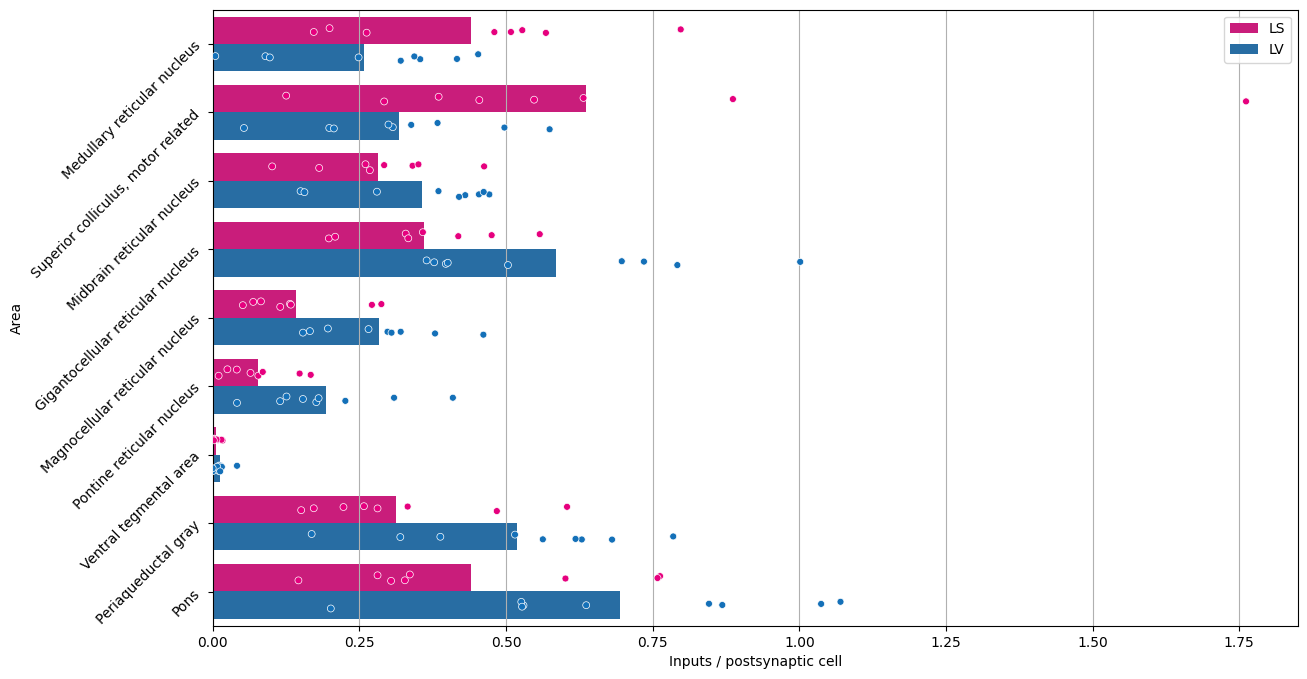

In [49]:
bt.grouped = True # False plots datasets individually, True plots as injection site groups
f, ax = plt.subplots(figsize=(14,8))
btp.generate_custom_plot(sig_areas, title='', normalisation='postsynaptics', ax=ax)
plt.yticks(rotation=45)
#btf.save(f'posterDimFrench_significant_{title}', as_type='pdf')
# PLOT HISTOGRAM OF ALL DATASETS ACROSS AREAS
# provide areas, title, normalisation ['postsynaptics':per starter, 'ch1':% all, None:#cells]

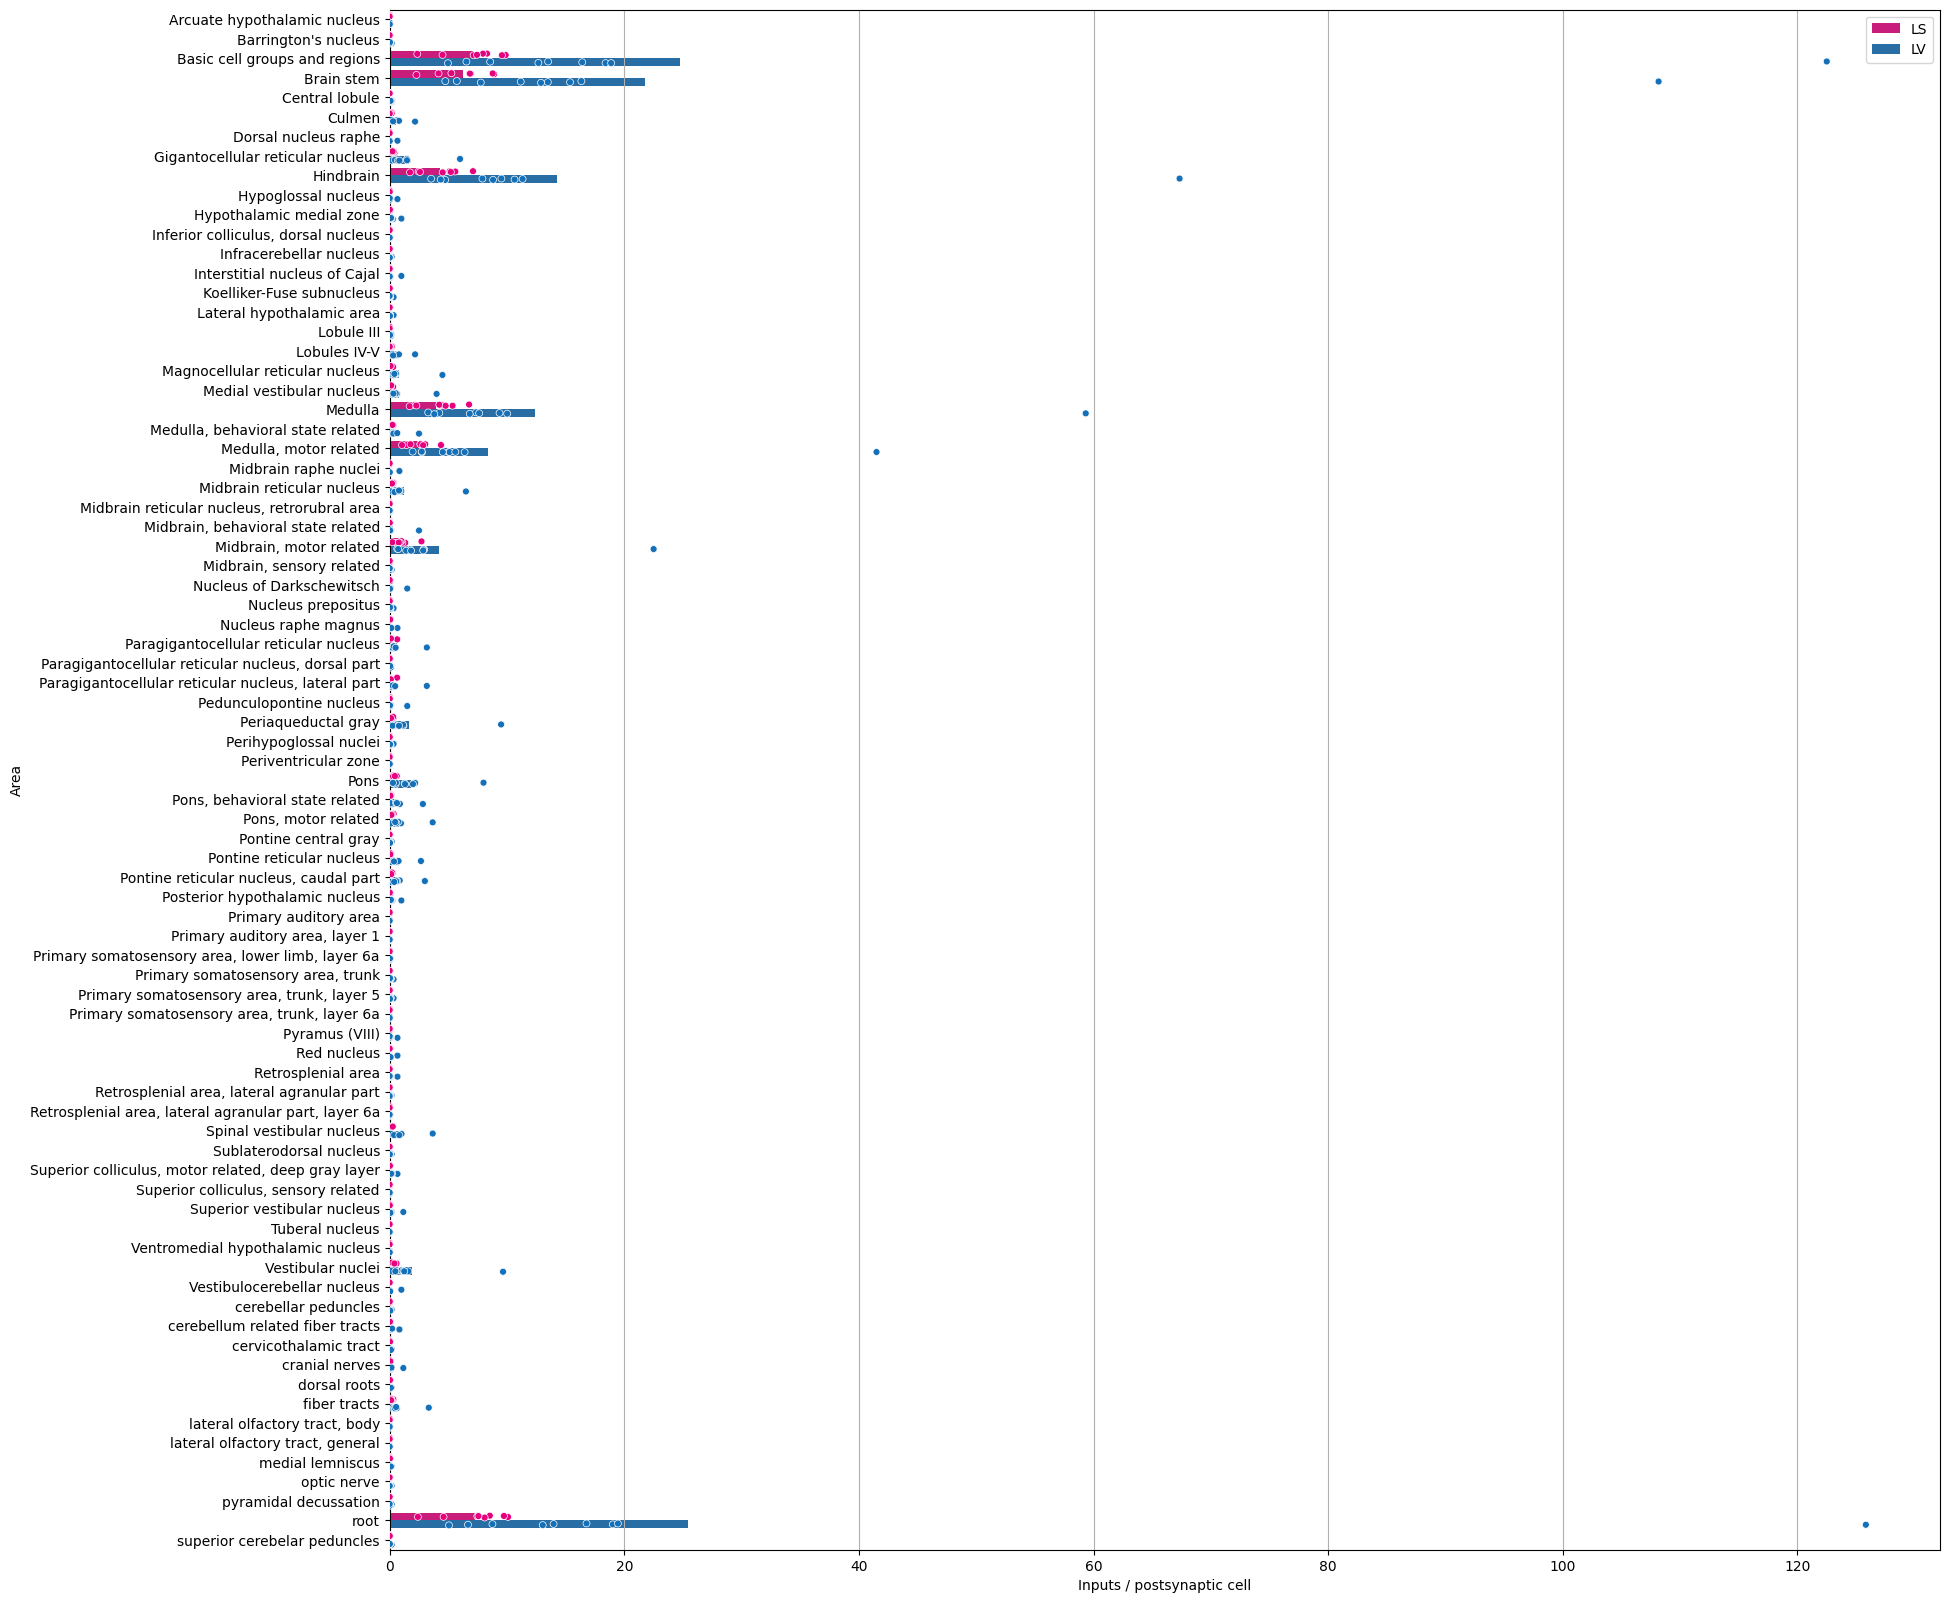

In [16]:
sig_list = [i for i in bt.area_indexes['acronym'] if bt.mwu(i)[1] < 0.05]
f, ax1 = plt.subplots(figsize=(20,20))
f.set_facecolor('white')
btp.generate_custom_plot(sig_list, title='', normalisation='postsynaptics', ax=ax1)
#btf.save(f'significant_{title}', as_type='png')
# show significantly different areas for an overview

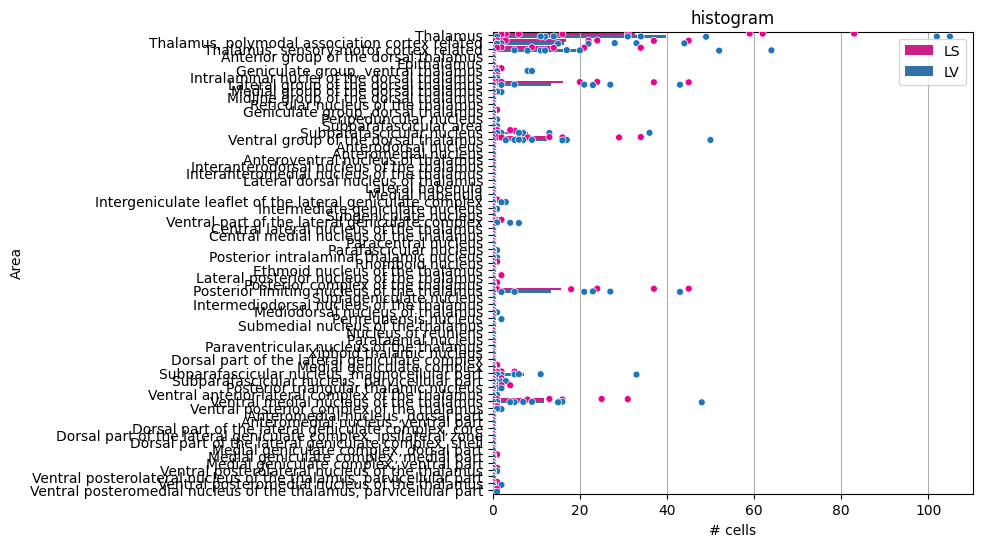

In [13]:
parent, children = bt.children_from(549, depth=0)
areas = [parent] + children
btp.custom_plot('r', areas, normalisation=None, title='histogram', log=False)

(17, 3)
(3,)
[]


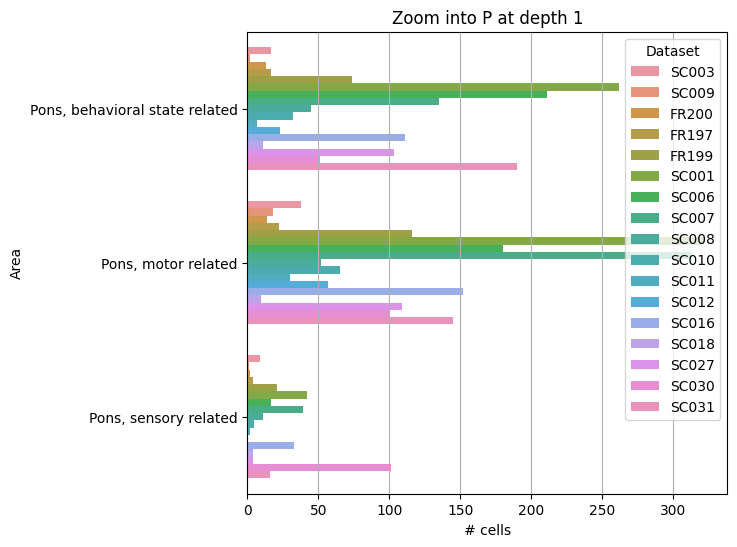

In [9]:
btp.zoom_plot('r', 'P', depth=1, threshold=0.5)
# zoom plots show areas within a parent region at given depth(s)
# depth=0 for all children, depth=1/2/3 for specified slice through inheritance tree

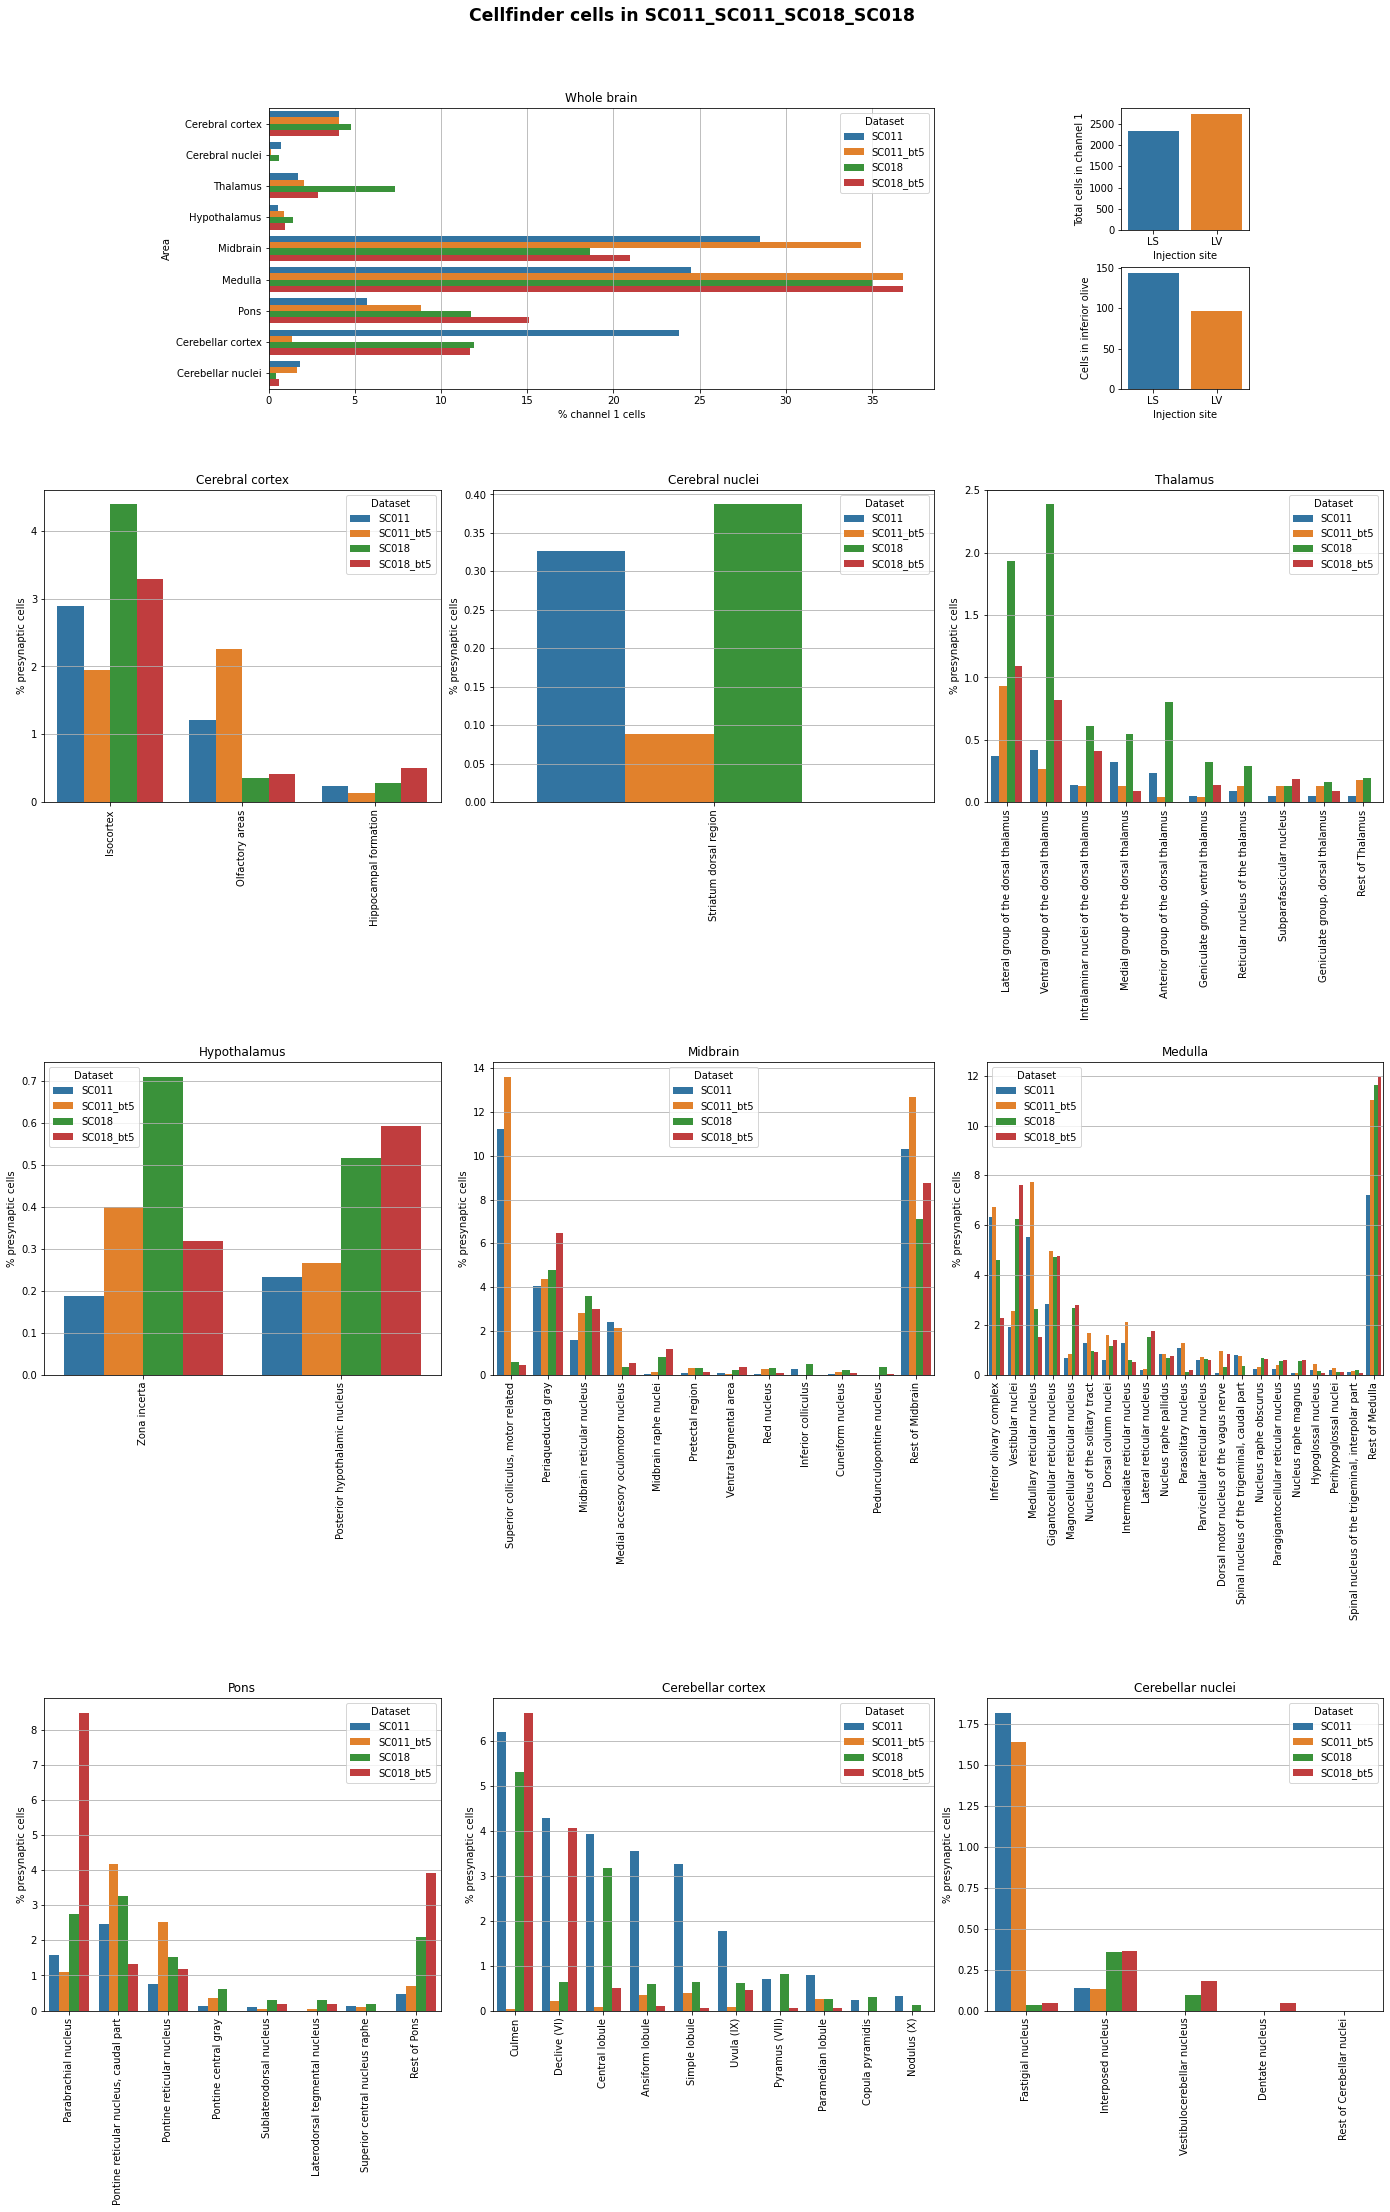

In [7]:
btp.generate_mega_overview_figure(f'Cellfinder cells in {title}')
#btf.save(f'areas_overview_{title}', as_type='png')

## Heatmaps

In [1]:
btp.generate_heatmap('r', bt.datasets[3], position=6500, vmax=None, normalisation='total', legend=False)
#btf.save('FR200_overview_heatmap', as_type='png')
# show heatmap for one dataset

NameError: name 'btp' is not defined

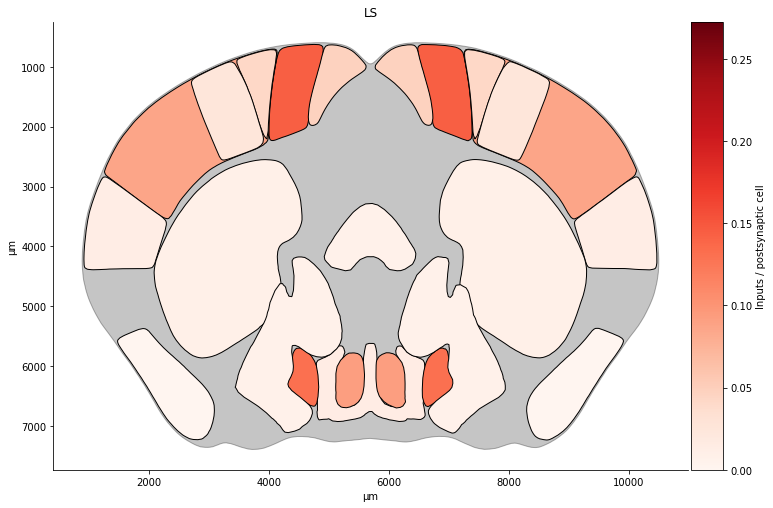

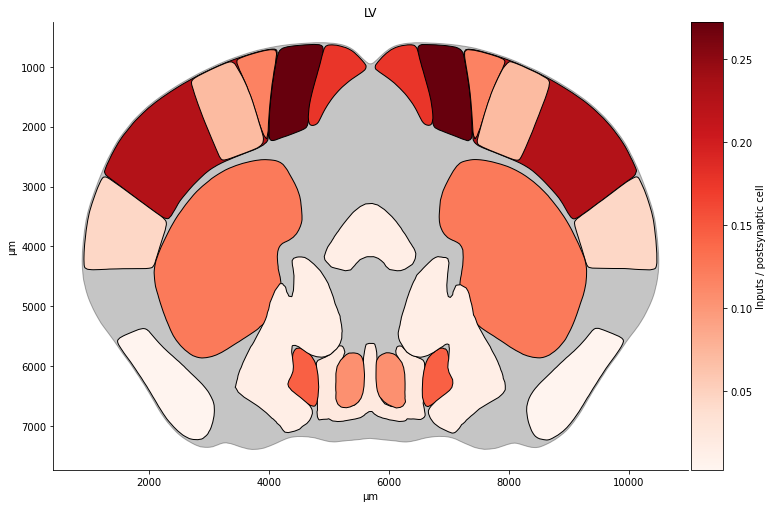

In [7]:
btp.generate_heatmap_comparison(ctx, orientation='frontal', position=5500, normalisation='postsynaptics', legend=False)
#btf.save(f'ctx_comparison_{title}', as_type='jpg')
# show heatmap of means by group

['LRNm', 'LRNp', 'MDRNd', 'MDRNv', 'AMBd', 'AMBv', 'PGRNd', 'PGRNl', 'NR', 'PRP', 'LAV', 'MV', 'SPIV', 'SUV', 'DCO', 'VCO', 'CU', 'GR', 'KF', 'SOCl', 'SOCm', 'POR', 'FF', 'LM', 'MM', 'SUM', 'TM', 'AD', 'AM', 'AV', 'IAD', 'IAM', 'LD', 'LH', 'MH', 'IGL', 'IntG', 'SubG', 'LGv', 'CL', 'CM', 'PCN', 'PF', 'PIL', 'RH', 'Eth', 'LP', 'PO', 'POL', 'SGN', 'IMD', 'MD', 'PR', 'SMT', 'RE', 'PT', 'PVT', 'Xi', 'LGd', 'MG', 'SPFm', 'SPFp', 'PoT', 'VAL', 'VM', 'VP', 'IPA', 'IPC', 'IPDL', 'IPDM', 'IPI', 'IPL', 'IPR', 'IPRL', 'CA', 'DG', 'FC', 'IG', 'APr', 'ENT', 'HATA', 'PAR', 'POST', 'PRE', 'ProS', 'SUB', 'AId', 'AIp', 'AIv', 'ACAd', 'ACAv', 'AUDd', 'AUDpo', 'AUDp', 'AUDv', 'ECT1', 'ECT2/3', 'ECT5', 'ECT6a', 'ECT6b', 'FRP1', 'FRP2/3', 'FRP5', 'FRP6a', 'FRP6b', 'GU1', 'GU2/3', 'GU4', 'GU5', 'GU6a', 'GU6b', 'ILA1', 'ILA2/3', 'ILA5', 'ILA6a', 'ILA6b', 'ORBl', 'ORBm', 'ORBvl', 'PERI1', 'PERI2/3', 'PERI5', 'PERI6a', 'PERI6b', 'VISa', 'VISrl', 'PL1', 'PL2/3', 'PL5', 'PL6a', 'PL6b', 'RSPd', 'RSPagl', 'RSPv', '

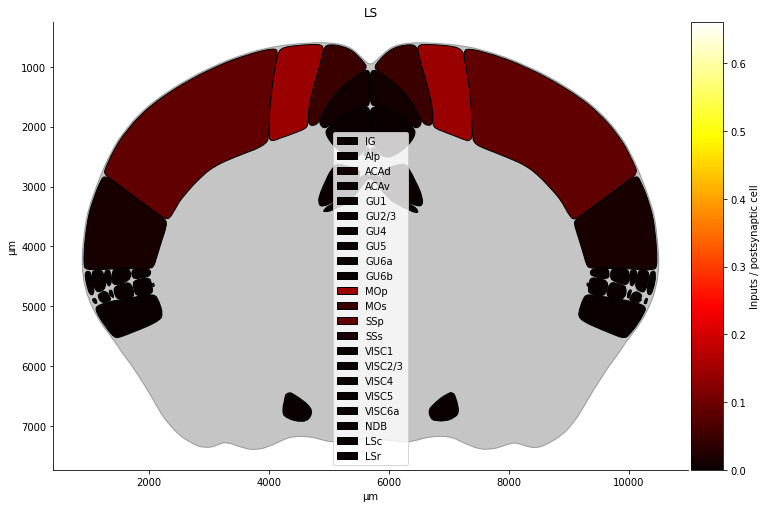

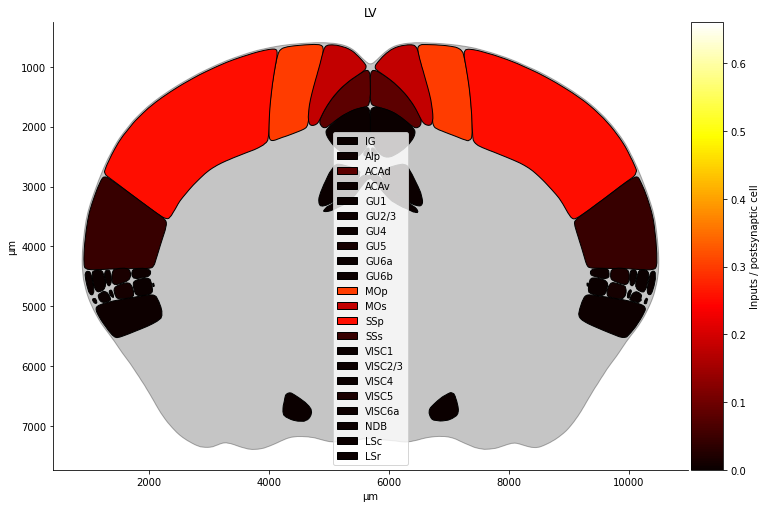

In [15]:
btp.generate_slice_heatmap(position=5500, normalisation='postsynaptics', depth=7)
# show heatmap of areas by depth in inheritance tree (frequently crashes)

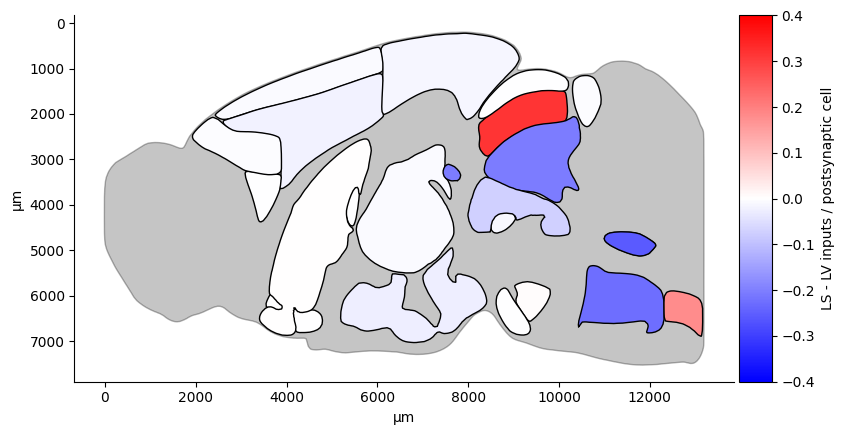

In [31]:
btp.generate_heatmap_difference(areas_6100, orientation='sagittal', position=6100, normalisation='postsynaptics', legend=False, limit=0.4)
#btf.save('heatmap_differences_absolute', as_type='png')
# show difference heatmap across groups

In [5]:
# convert area codes to acronyms
codes = [313, 688, 354, 771, 1097, 549, 323, 379, 370, 386, 1117, 987, 290, 128, 795, 294, 230, 1048, 136, 235, 307, 395, 938, 852, 701, 720, 651, 437, 146, 1093, 797, 10, 17, 500, 453, 955, 1098, 1107, 978, 202, 225, 711, 985]
names = bt.area_indexes.loc[codes]['acronym'].tolist()

[]


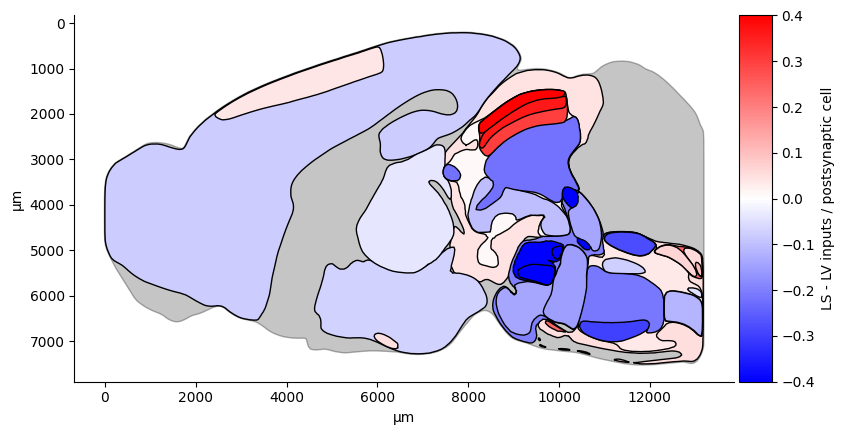

In [27]:
btp.generate_heatmap_ratios(names, orientation='sagittal', position=6100, normalisation='postsynaptics', legend=False, limit=0.4, add=False)
# show ratio difference heatmap across groups

## Statistics

In [33]:
bt.mwu('r', 'PAG', norm='postsynaptics')

MannwhitneyuResult(statistic=14.0, pvalue=0.03595228301110654)

In [109]:
bt.mwu('r', True, 'IO', norm='custom_pedestal')

MannwhitneyuResult(statistic=16.0, pvalue=0.02857142857142857)

In [5]:
areas = [1129, 313, 688, 354, 771, 1097, 549, 323, 379, 370, 386, 1117, 987, 290, 128, 795, 294, 230, 1048, 136, 235, 307, 395, 938, 852, 701, 720, 651, 437, 146, 1093, 797, 10, 17, 500, 453, 955, 1098, 1107, 978, 202, 225, 711, 985]

In [9]:
areas = bt.area_indexes.loc[areas, 'acronym'].tolist()

In [28]:
#areas = ['VTA','SCm','TH']
bt.anova('r', True, areas, parametric=True, norm='custom_division')

                          Area Dataset     Cells
0            Vestibular nuclei      LS  0.173870
1                 Pontine gray      LS  2.501045
2  Tegmental reticular nucleus      LS  1.350492
3    Lateral reticular nucleus      LS  0.270254
4      Infracerebellar nucleus      LS  0.113747
                          Area Dataset  Cells
0            Vestibular nuclei      LS  181.0
1                 Pontine gray      LS  227.0
2  Tegmental reticular nucleus      LS  221.0
3    Lateral reticular nucleus      LS  199.0
4      Infracerebellar nucleus      LS  173.0


,sum_sq,df,F,PR(>F)
C(Area),731612.750000,28.0,23.633579,1.814011e-45
C(Dataset),7716.568966,1.0,6.979599,8.995717e-03
C(Area):C(Dataset),108876.181034,28.0,3.517071,1.936350e-07
Residual,192372.500000,174.0,NaN,NaN
